# Phase 2 Nutrient Analysis

In [225]:
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

In [226]:
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Oyster_Nutrient_Data")
getwd()

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Oyster_Nutrient_Data"

## 0. Data Formatting

In [227]:
working <- read_csv("Phase2_Nutrient/Phase2_nutrient_working.csv")
preprocessing <- read_csv("NutrientPreprocessing/Oyster_Nutrient_Processing_Phase2.1.csv")

Rows: 384 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): Vial_num, n_notes, c_notes, n_exclude
dbl (4): linear_corr_d15n, wt_percent_n, linear_corr_d13c, wt_percent_c
lgl (1): c_exclude

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 384 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): Phase_1_treat, Phase_1_treat_old, Phase_2_treat, Phase_2_treat_old, Tag_color, Tissue_type, Sample_Name_ol...
dbl  (6): Year, Phase_1_rep, Phase_2_rep, Tag_num, Vial_num, og_order

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [228]:
colnames(working);colnames(preprocessing)

[1] "Vial_num"         "linear_corr_d15n" "wt_percent_n"     "n_notes"          "linear_corr_d13c" "wt_percent_c"    
[7] "c_notes"          "n_exclude"        "c_exclude"

[1] "Year"              "Phase_1_treat"     "Phase_1_treat_old" "Phase_1_rep"       "Phase_2_treat"    
 [6] "Phase_2_treat_old" "Phase_2_rep"       "Tag_color"         "Tag_num"           "Tissue_type"      
[11] "Sample_Name_old"   "Sample_Name"       "Vial_num"          "Notes"             "og_order"         
[16] "filt_out"

In [229]:
#Add in treatment groups etc. by vial number
matched_data <- working %>%
  mutate(Vial_num = as.character(Vial_num)) %>%
  inner_join(
    Preprocessing %>%
      mutate(Vial_num = as.character(Vial_num)),
    by = "Vial_num")%>%
select(- c(Sample_Name_old, og_order, filt_out, Phase_1_treat_old, Phase_2_treat_old))

In [230]:
colnames(matched_data)

[1] "Vial_num"         "linear_corr_d15n" "wt_percent_n"     "n_notes"          "linear_corr_d13c" "wt_percent_c"    
 [7] "c_notes"          "n_exclude"        "c_exclude"        "Year"             "Phase_1_treat"    "Phase_1_rep"     
[13] "Phase_2_treat"    "Phase_2_rep"      "Tag_color"        "Tag_num"          "Tissue_type"      "Sample_Name"     
[19] "Notes"

In [231]:
View(matched_data)

Vial_num,linear_corr_d15n,wt_percent_n,n_notes,linear_corr_d13c,wt_percent_c,c_notes,n_exclude,c_exclude,Year,Phase_1_treat,Phase_1_rep,Phase_2_treat,Phase_2_rep,Tag_color,Tag_num,Tissue_type,Sample_Name,Notes
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,13.4,0.2,NA,-9.5,17.4,NA,NA,NA,2024,Warm,6,Warm,6,G,72,S,2024_Warm06_Warm06_G72_S,May have bee tag in sample
2,11.9,0.2,NA,-7.4,15.9,NA,NA,NA,2024,Hyp,5,Warm,6,B,69,S,2024_Hyp05_Warm06_B69_S,NA
3,9.6,0.3,NA,-10.2,18.1,NA,NA,NA,2024,Both,6,Warm,6,O,72,S,2024_Both06_Warm06_O72_S,NA
4,12.6,10.0,NA,-24.0,39.3,NA,NA,NA,2024,Warm,6,Warm,6,G,72,T,2024_Warm06_Warm06_G72_T,NA
5,12.5,10.1,NA,-23.8,41.6,NA,NA,NA,2024,Hyp,5,Warm,6,B,69,T,2024_Hyp05_Warm06_B69_T,NA
6,12.4,8.8,NA,-23.6,39.2,NA,NA,NA,2024,Both,6,Warm,6,O,72,T,2024_Both06_Warm06_O72_T,NA
7,12.7,7.0,NA,-25.7,49.1,NA,NA,NA,2024,Both,3,Warm,6,O,66,T,2024_Both03_Warm06_O66_T,NA
8,12.2,6.8,NA,-26.2,54.9,NA,NA,NA,2024,Cont,2,Warm,6,W,63,T,2024_Cont02_Warm06_W63_T,NA
9,12.5,7.3,NA,-26.2,52.8,NA,NA,NA,2024,Warm,5,Warm,6,G,69,T,2024_Warm05_Warm06_G69_T,NA


In [79]:
#write csv
#write_csv(matched_data, "Phase2_Nutrient/Phase2_nutrient_merged.csv")

In [232]:
#set contrasts
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum"  "contr.poly"

In [233]:
## READ IN MERGED DATA
df <- read_csv("Phase2_nutrient/Phase2_nutrient_merged.csv")

Rows: 392 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): Vial_num, n_notes, c_notes, n_exclude, c_exclude, Phase_1_treat, Phase_1_rep_R, Phase_2_treat, Phase_2_rep...
dbl  (8): linear_corr_d15n, wt_percent_n, linear_corr_d13c, wt_percent_c, Year, Phase_1_rep, Phase_2_rep, Tag_num

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Tissue

## 1. % Nitrogen in Tissue

In [234]:
colnames(df)
unique(df$Tissue_type)

[1] "Vial_num"         "linear_corr_d15n" "wt_percent_n"     "n_notes"          "linear_corr_d13c" "wt_percent_c"    
 [7] "c_notes"          "n_exclude"        "c_exclude"        "Year"             "Phase_1_treat"    "Phase_1_rep"     
[13] "Phase_1_rep_R"    "Phase_2_treat"    "Phase_2_rep"      "Phase_2_rep_R"    "Tag_color"        "Tag_num"         
[19] "Tissue_type"      "Sample_Name"      "Notes"            "Phase_1_DO"       "Phase_1_temp"     "Phase_2.1_DO"    
[25] "Phase_2.1_temp"

[1] "S" "T"

In [235]:
#filter data
Tissue_Nitrogen <- df%>%
filter(Tissue_type == "T")%>%
filter(is.na(n_exclude))

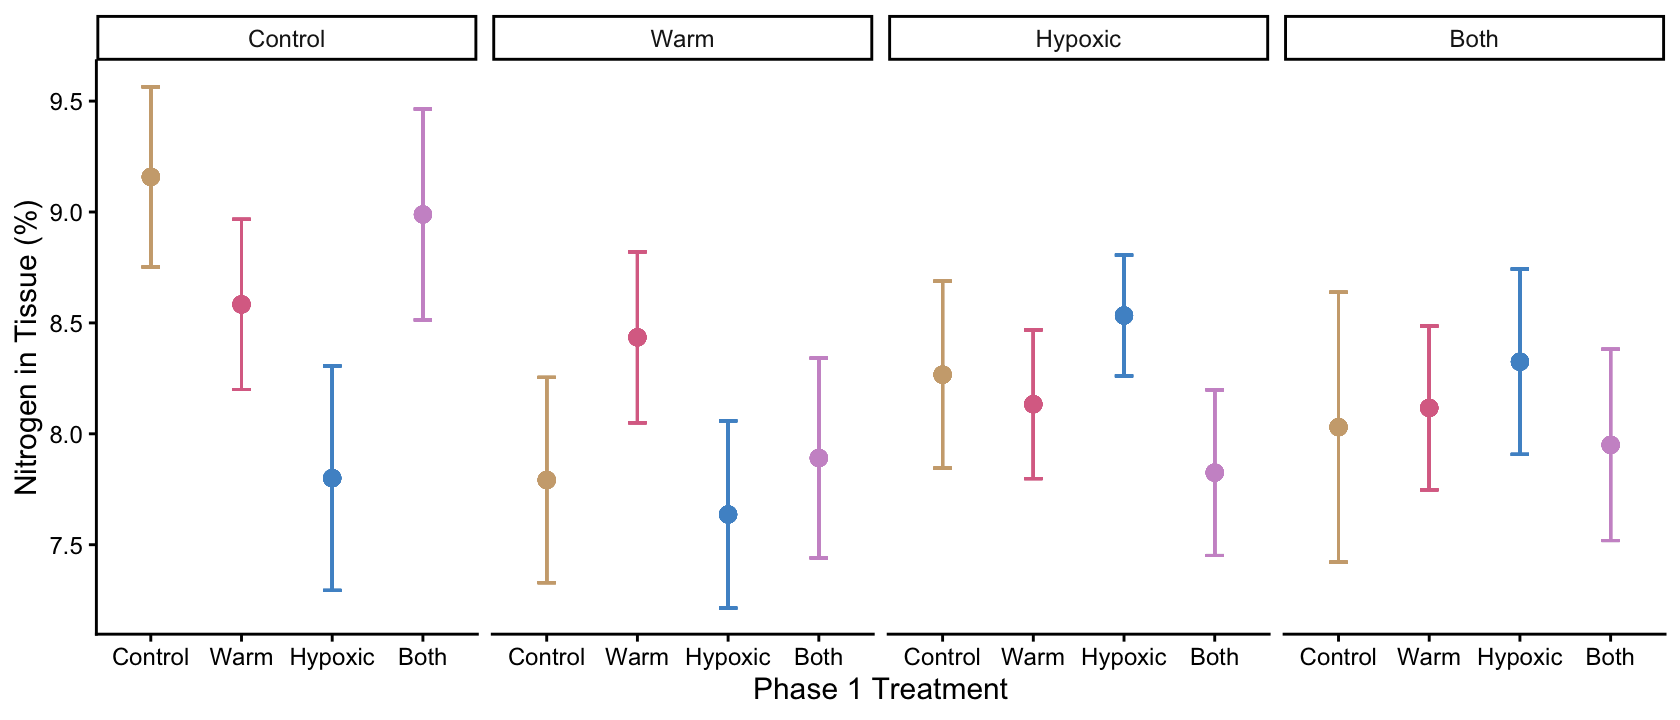

In [236]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Tissue_Nitrogen %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(wt_percent_n, na.rm = TRUE),
    se_growth = std.error(wt_percent_n, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Nitrogen in Tissue (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [237]:
##tissue nitrogen
m1 <- lmer(wt_percent_n~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_Nitrogen, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.460607e+03,1,17.995337,0.0000
Phase_1_DO,1.002611e+00,1,9.336845,0.3419
Phase_1_temp,1.009569e-01,1,12.424869,0.7560
Phase_2.1_temp,1.402046e+00,1,19.946527,0.2503
Phase_2.1_DO,2.789255e-01,1,19.945471,0.6032
Phase_1_DO:Phase_1_temp,8.286588e-02,1,9.338071,0.7797
Phase_1_DO:Phase_2.1_temp,1.415350e-02,1,19.476957,0.9065
Phase_1_temp:Phase_2.1_temp,1.556939e-01,1,19.660839,0.6974
Phase_1_DO:Phase_2.1_DO,1.046116e+00,1,19.452557,0.3190


Nothing significant

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.540328,0.9146876
,166,NA,NA


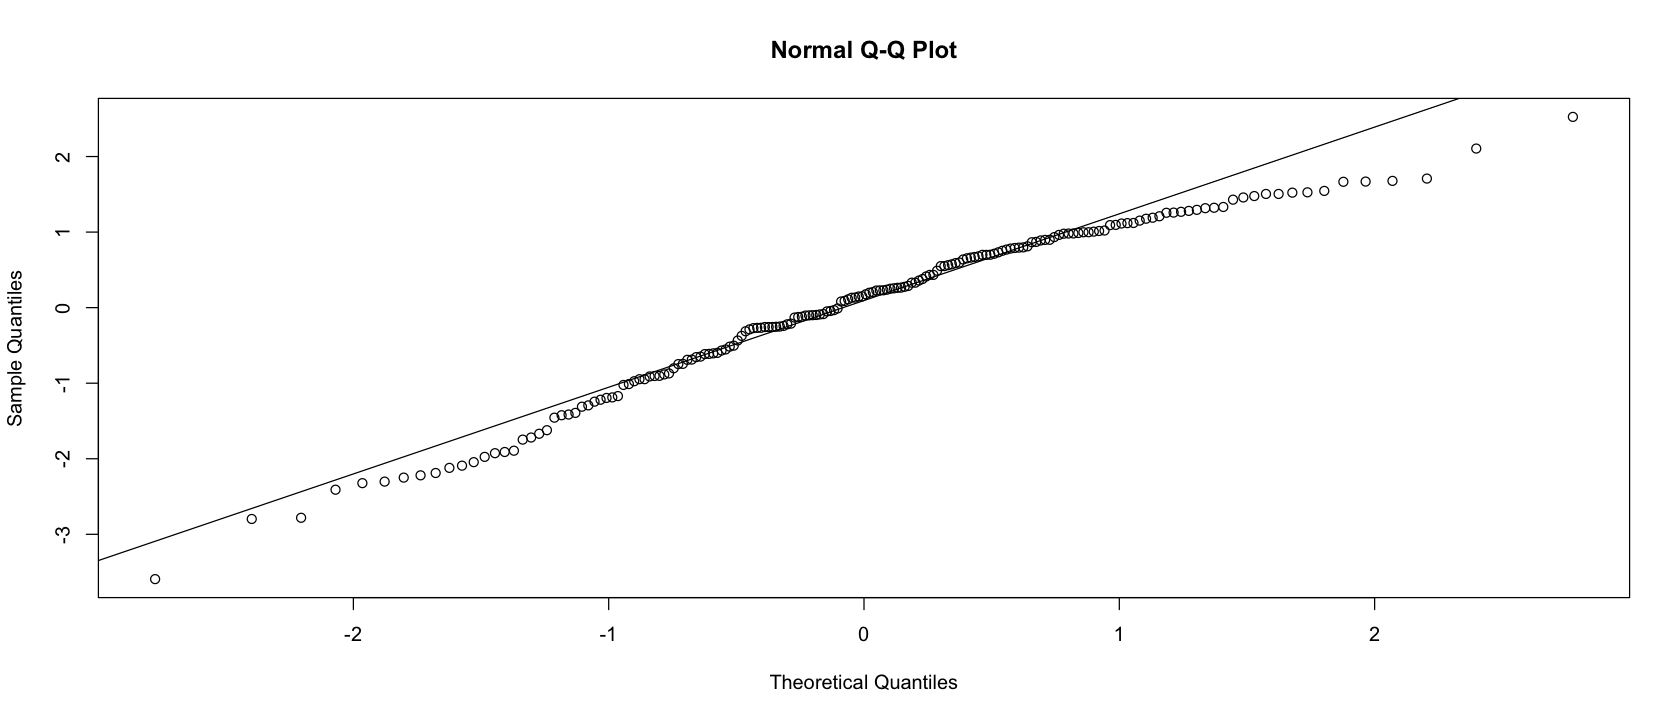

In [238]:
#diagnostics
leveneTest(wt_percent_n~Phase_1_treat*Phase_2_treat, Tissue_Nitrogen) 
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

## 2. % Carbon in Tissue

In [239]:
#filter data
Tissue_Carbon <- df%>%
filter(Tissue_type == "T")%>%
filter(is.na(c_exclude))

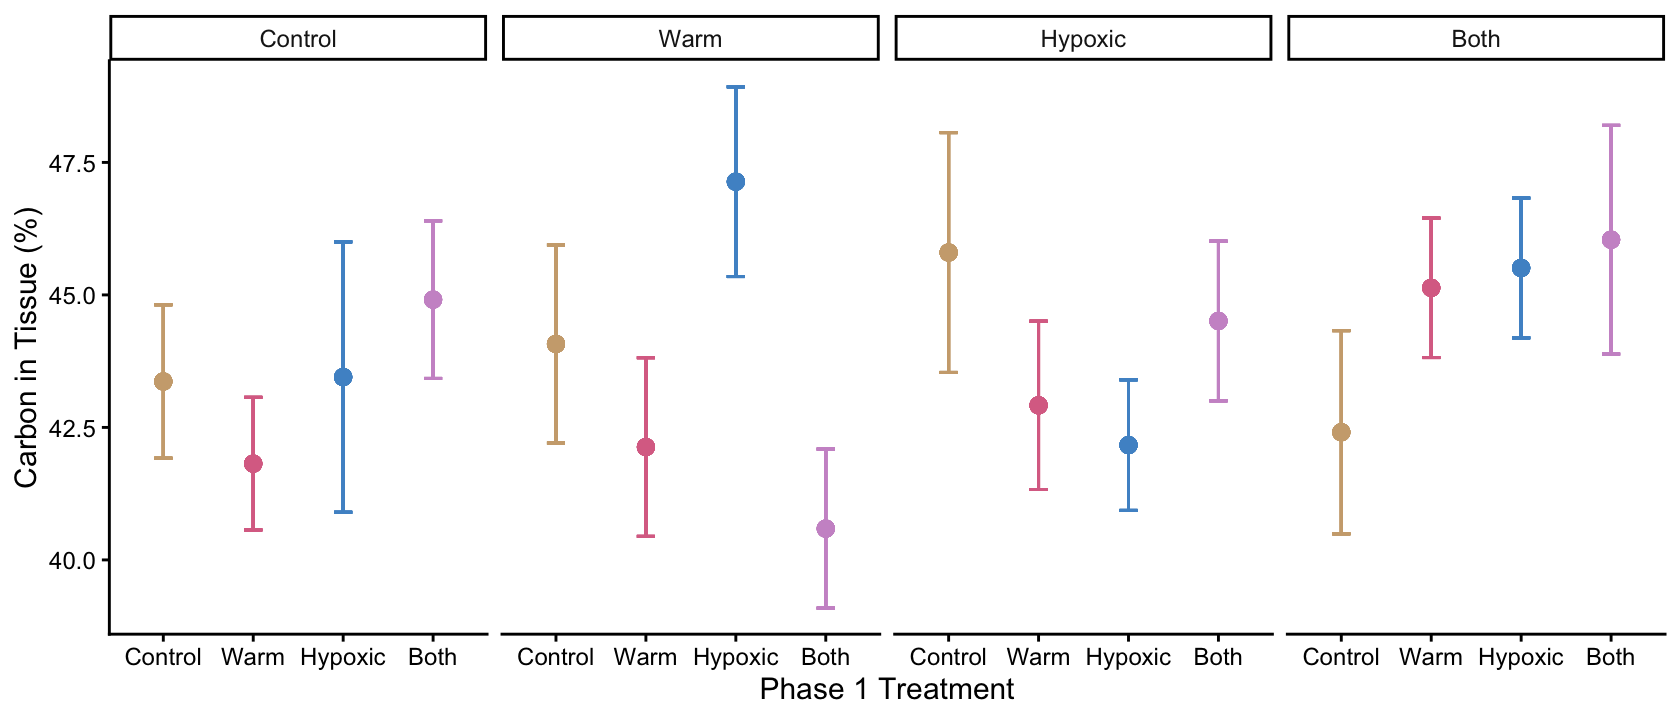

In [240]:
#tissue carbon
summary_stats_t <- Tissue_Carbon %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(wt_percent_c, na.rm = TRUE),
    se_growth = std.error(wt_percent_c, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Carbon in Tissue (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [241]:
##tissue carbon
m2 <- lmer(wt_percent_c~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_Carbon, REML=TRUE)
aov_tab<-Anova(m2, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),4.404600e+03,1,18.42064,0.0000
Phase_1_DO,9.712223e-01,1,10.60208,0.3463
Phase_1_temp,5.353824e-01,1,12.55844,0.4778
Phase_2.1_temp,2.360766e-01,1,19.75749,0.6324
Phase_2.1_DO,3.511163e-01,1,19.75507,0.5602
Phase_1_DO:Phase_1_temp,1.280955e-02,1,10.60697,0.9120
Phase_1_DO:Phase_2.1_temp,5.253806e-01,1,19.10093,0.4773
Phase_1_temp:Phase_2.1_temp,3.109066e-01,1,19.26239,0.5835
Phase_1_DO:Phase_2.1_DO,1.488905e-01,1,19.07223,0.7039


In [195]:
#posthocs
options(width = 120)
emmeans(m2,specs = pairwise ~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO Phase_1_temp Phase_2.1_temp emmean   SE   df lower.CL upper.CL
 Hyp        Ambient      Ambient          42.8 1.35 46.2     40.1     45.5
 Norm       Ambient      Ambient          44.6 1.35 46.2     41.9     47.3
 Hyp        Warm         Ambient          44.7 1.44 54.5     41.8     47.5
 Norm       Warm         Ambient          42.4 1.35 46.2     39.6     45.1
 Hyp        Ambient      Warm             46.4 1.38 48.6     43.7     49.2
 Norm       Ambient      Warm             43.2 1.38 48.6     40.4     46.0
 Hyp        Warm         Warm             43.4 1.38 48.6     40.7     46.2
 Norm       Warm         Warm             43.9 1.41 49.8     41.0     46.7

Results are averaged over the levels of: Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate   SE   df t.ratio p.value
 Hyp Ambient Ambient - Norm Ambient Ambient  -1.7750 1.57 26.1  -1.128  0.2698
 Hyp Ambient Ambien

In [196]:
#Normoxic Warm Ambient - Hypoxic Ambient Warm p = 0.0414
    #warm ambient(42.4) - hypoxic warm (46.4)

#not a strong indication of anything in particular

#Hyp Ambient Ambient - Hyp Ambient Warm p = 0.0599
#Hyp Ambient Warm - Norm Ambient Warm p = 0.0551

#Hyp Ambient Warm
    #hypoxic warm differs from warm ambient, hypoxic ambient, and control warm

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.6587568,0.8217245
,168,NA,NA


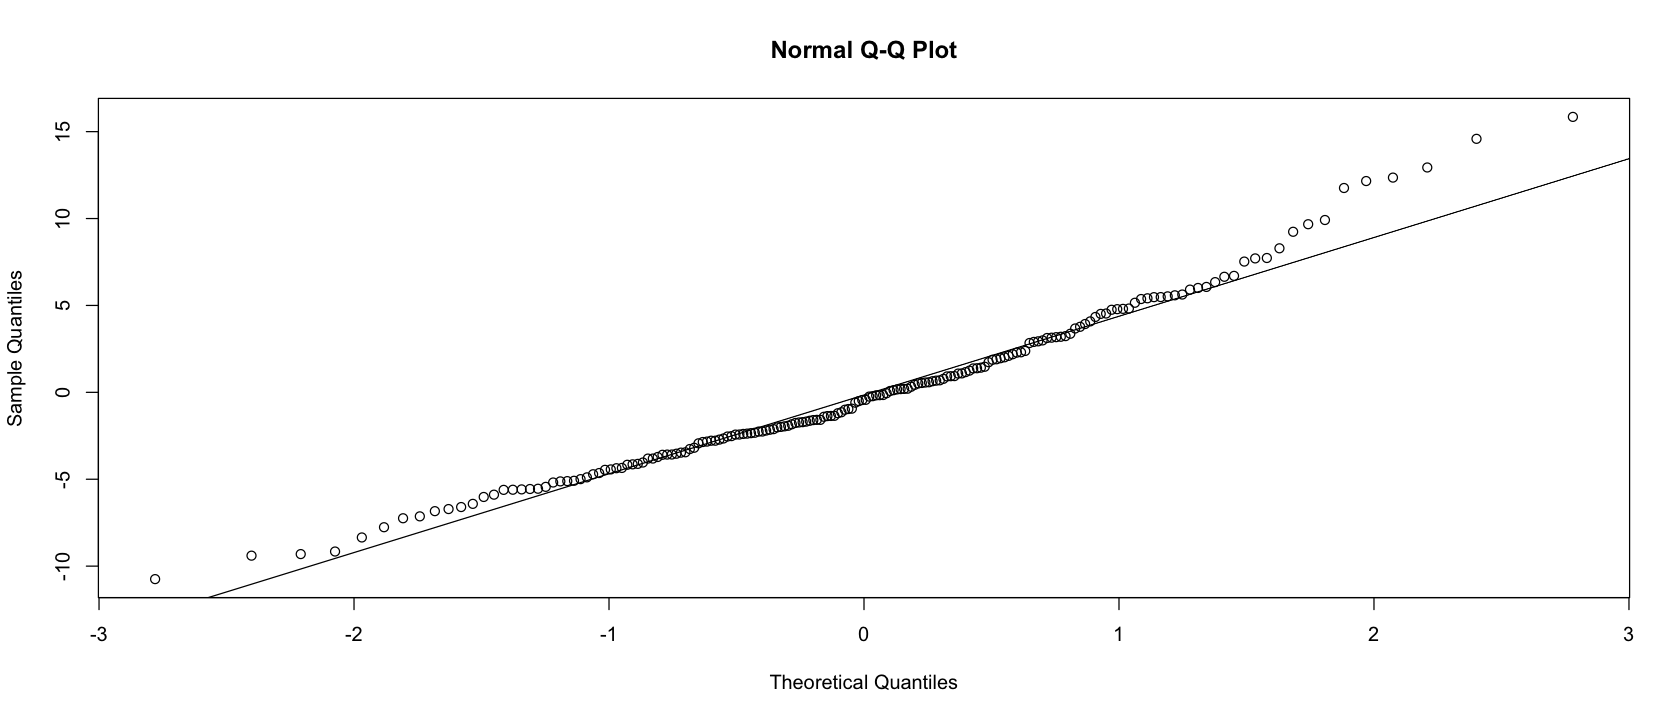

In [242]:
#diagnostics
leveneTest(wt_percent_c~Phase_1_treat*Phase_2_treat, Tissue_Carbon) 
m1.e <- residuals(m2) 
qqnorm(m1.e)
qqline(m1.e)

## 3. Carbon:Nitrogen in Tissue

In [243]:
#filter data
Tissue_CN <- df%>%
filter(Tissue_type == "T")%>%
filter(is.na(n_exclude))%>%
filter(is.na(c_exclude))

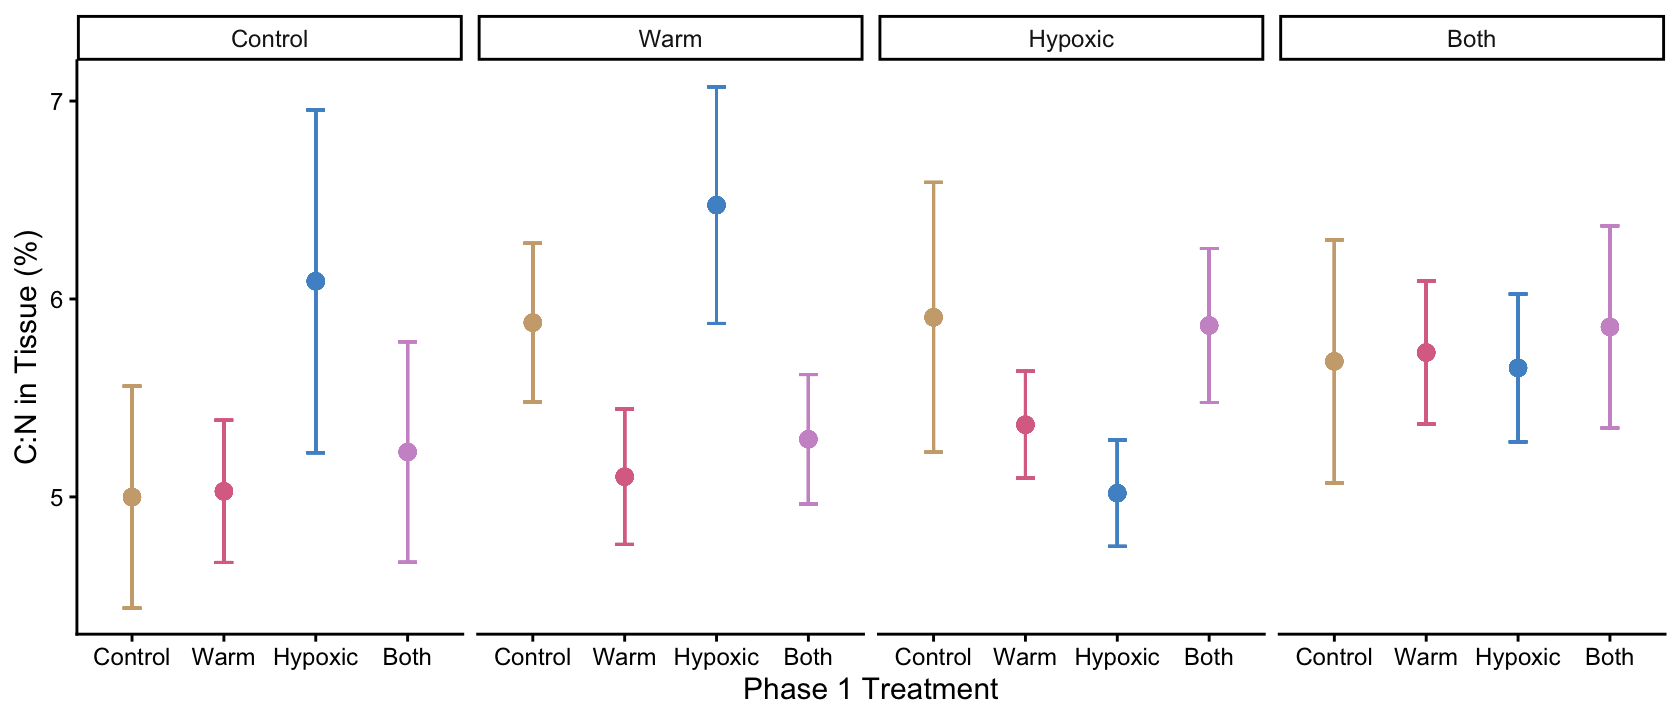

In [244]:
#tissue c:n
summary_stats_t <- Tissue_CN %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean((wt_percent_c/wt_percent_n), na.rm = TRUE),
    se_growth = std.error((wt_percent_c/wt_percent_n), na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "C:N in Tissue (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [245]:
##tissue carbon:nitrogen
m3 <- lmer((wt_percent_c/wt_percent_n)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_CN, REML=TRUE)
aov_tab<-Anova(m3, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),8.666382e+02,1,17.736215,0.0000
Phase_1_DO,1.012578e+00,1,9.302556,0.3397
Phase_1_temp,1.148062e+00,1,13.062418,0.3034
Phase_2.1_temp,5.795778e-01,1,19.935732,0.4554
Phase_2.1_DO,1.373187e-01,1,19.934486,0.7149
Phase_1_DO:Phase_1_temp,4.838243e-03,1,9.303681,0.9460
Phase_1_DO:Phase_2.1_temp,1.558996e-02,1,19.465815,0.9019
Phase_1_temp:Phase_2.1_temp,2.025274e-01,1,19.700347,0.6576
Phase_1_DO:Phase_2.1_DO,1.489019e+00,1,19.441349,0.2370


Nothing significant

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.5807604,0.8867979
,166,NA,NA


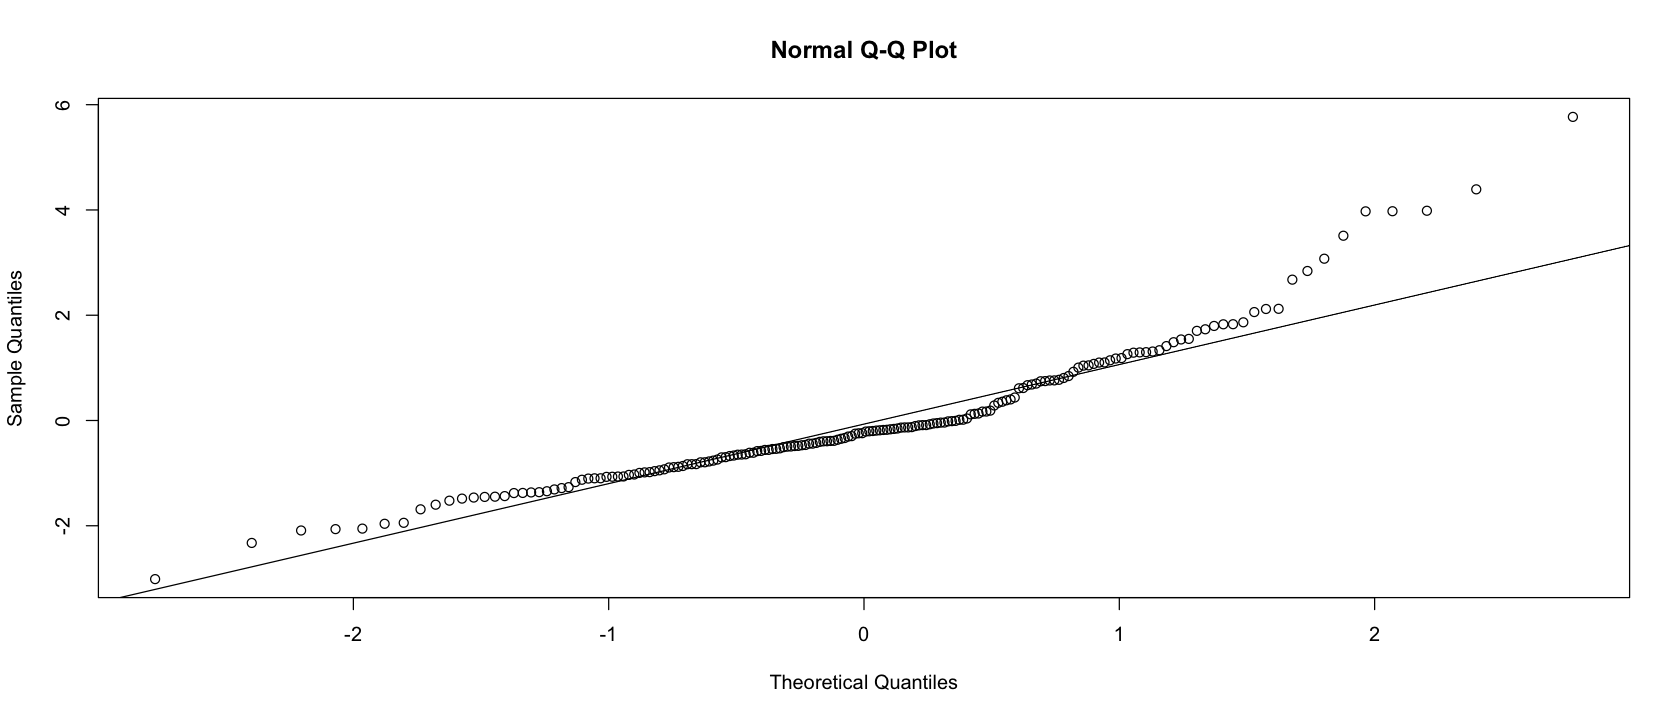

In [246]:
#diagnostics
leveneTest((wt_percent_c/wt_percent_n)~Phase_1_treat*Phase_2_treat, Tissue_CN) 
m1.e <- residuals(m3)
qqnorm(m1.e)
qqline(m1.e)

## 4. Mg Carbon and Nitrogen in Tissue

In [247]:
# Read in growth dataset
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC")
weight_df <- read_csv("Oyster_Weight_Data/growth_phase2.1_weightsSKM.csv")

Rows: 1152 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (20): Sample_Name, Date_MMDDYYYY_pre, Phase_1_treat, Phase_1_rep, Phase_2_treat, Phase_2_rep, Tag_color, Notes_p...
dbl (17): Order_pre, Year, Tag_num, Submerged_weight_pre, Dry_weight_pre, Order_post, Date_MMDDYYYY_post, Submerged_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [248]:
#calculate % N averages Tissue

summary_stats_t <- Tissue_CN %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  summarize(
    mean_N = mean(wt_percent_n, na.rm = TRUE),
    mean_C = mean(wt_percent_c, na.rm = TRUE))

print(summary_stats_t)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Phase_1_treat and Phase_2_treat.
ℹ Output is grouped by Phase_1_treat.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Phase_1_treat, Phase_2_treat))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


# A tibble: 16 × 4
# Groups:   Phase_1_treat [4]
   Phase_1_treat Phase_2_treat mean_N mean_C
   <chr>         <chr>          <dbl>  <dbl>
 1 Both          Both            7.95   44.6
 2 Both          Cont            8.99   44.9
 3 Both          Hyp             7.82   44.5
 4 Both          Warm            7.89   40.6
 5 Cont          Both            8.03   42.6
 6 Cont          Cont            9.16   43.4
 7 Cont          Hyp             8.27   45.8
 8 Cont          Warm            7.79   44.1
 9 Hyp           Both            8.32   45.5
10 Hyp           Cont            7.8    43.4
11 Hyp           Hyp             8.53   42.2
12 Hyp           Warm            7.64   47.1
13 Warm          Both            8.12   45.1
14 Warm          Cont            8.58   41.8
15 Warm          Hyp             8.13   42.9
16 Warm          Warm            8.44   42.1


In [249]:
Tissue_Nutrients <- weight_df %>%
  filter(Exclude_all != "Y" | is.na(Exclude_all)) %>%
  left_join(
    summary_stats_t,
    by = c("Phase_1_treat", "Phase_2_treat")) %>%
  mutate(mgN_tissue_P2 = (Actual_tissue_post_mg * mean_N) / 100)%>%
  mutate(mgC_tissue_P2 = (Actual_tissue_post_mg * mean_C) / 100)

View(Tissue_Nutrients)

Sample_Name,Order_pre,Date_MMDDYYYY_pre,Year,Phase_1_treat,Phase_1_rep,Phase_2_treat,Phase_2_rep,Tag_color,Tag_num,⋯,Phase_1_rep_R,Phase_2_rep_R,Ratio_tissue_shell_pre_mg,Phase1_Phase2_rep,Exclude_all,Exclude_pre_analysis,mean_N,mean_C,mgN_tissue_P2,mgC_tissue_P2
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2024_Both01_Both01_O1,3,7/23/24,2024,Both,01,Both,01,O,1,⋯,Both01,Both01,0.9025393,Both01_Both01,NA,NA,7.950000,44.57273,33.368567,187.08529
2024_Both01_Both01_O2,7,7/23/24,2024,Both,01,Both,01,O,2,⋯,Both01,Both01,0.6425681,Both01_Both01,NA,NA,7.950000,44.57273,23.357289,130.95573
2024_Both01_Both02_O13,50,7/23/24,2024,Both,01,Both,02,O,13,⋯,Both01,Both02,0.8083796,Both01_Both02,NA,NA,7.950000,44.57273,29.681796,166.41492
2024_Both01_Both02_O14,55,7/23/24,2024,Both,01,Both,02,O,14,⋯,Both01,Both02,0.5888140,Both01_Both02,NA,NA,7.950000,44.57273,29.167273,163.53018
2024_Both01_Both03_O25,98,7/24/24,2024,Both,01,Both,03,O,25,⋯,Both01,Both03,0.7725658,Both01_Both03,NA,NA,7.950000,44.57273,8.880419,49.78924
2024_Both01_Both03_O26,103,7/24/24,2024,Both,01,Both,03,O,26,⋯,Both01,Both03,0.5599379,Both01_Both03,NA,NA,7.950000,44.57273,15.915938,89.23481
2024_Both01_Both04_O37,214,7/24/24,2024,Both,01,Both,04,O,37,⋯,Both01,Both04,0.7191106,Both01_Both04,NA,NA,7.950000,44.57273,61.500580,344.81114
2024_Both01_Both04_O38,111,7/24/24,2024,Both,01,Both,04,O,38,⋯,Both01,Both04,0.5380885,Both01_Both04,NA,NA,7.950000,44.57273,7.566055,42.42009
2024_Both01_Both05_O49,260,7/25/24,2024,Both,01,Both,05,O,49,⋯,Both01,Both05,0.5206603,Both01_Both05,NA,NA,7.950000,44.57273,26.185484,146.81238


### 4.1 Mg Nitrogen Analysis

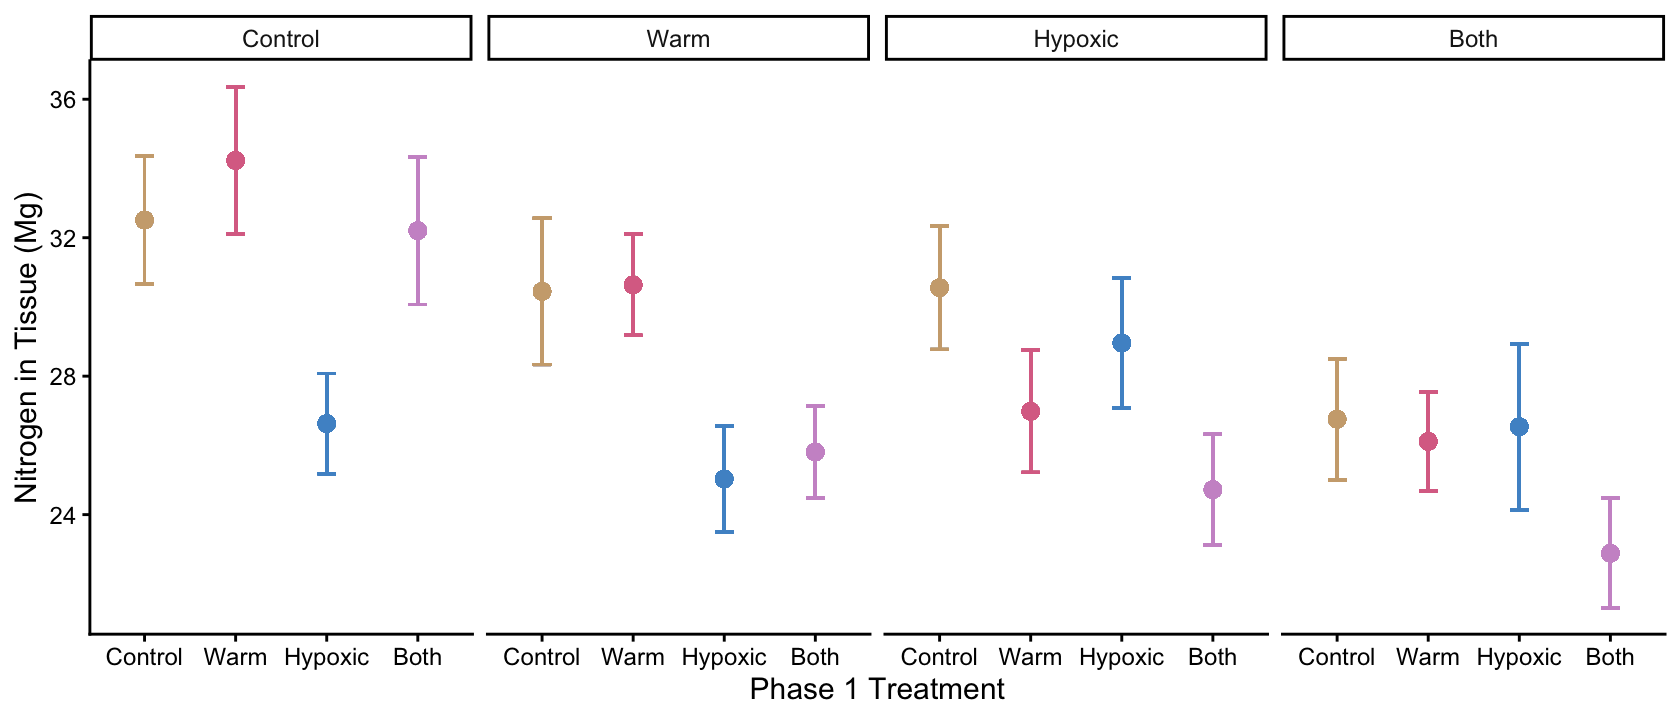

In [250]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Tissue_Nutrients %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgN_tissue_P2, na.rm = TRUE),
    se_growth = std.error(mgN_tissue_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Nitrogen in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [262]:
##tissue nitrogen
m1 <- lmer(mgN_tissue_P2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.738647e+02,1,23.88718,0.0000
Phase_1_DO,6.078182e+00,1,18.79308,0.0235
Phase_1_temp,1.379146e-01,1,16.84790,0.7150
Phase_2.1_temp,1.022468e+00,1,20.00037,0.3240
Phase_2.1_DO,1.219191e+00,1,20.00079,0.2826
Phase_1_DO:Phase_1_temp,8.556301e-03,1,16.85127,0.9274
Phase_1_DO:Phase_2.1_temp,7.078516e-02,1,19.99877,0.7929
Phase_1_temp:Phase_2.1_temp,2.298760e-01,1,19.98332,0.6368
Phase_1_DO:Phase_2.1_DO,2.185021e+00,1,20.00299,0.1549


In [252]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_1_DO, adjust = "none")
emmeans(m1,specs = pairwise ~ Phase_1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean  SE   df lower.CL upper.CL
 Hyp          26.6 1.6 30.4     23.3     29.9
 Norm         29.8 1.6 30.3     26.5     33.1

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate  SE   df t.ratio p.value
 Hyp - Norm    -3.19 1.3 18.8  -2.465  0.0235

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 


NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Ambient      Hyp            28.2 2.14 27.5     23.8     32.6
 Warm         Hyp            25.1 2.14 27.7     20.8     29.5
 Ambient      Norm           28.7 2.14 27.3     24.3     33.0
 Warm         Norm           30.8 2.14 27.7     26.4     35.2

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                   estimate   SE   df t.ratio p.value
 Ambient Hyp - Warm Hyp        3.057 1.48 23.7   2.064  0.0502
 Ambient Hyp - Ambient Norm   -0.453 2.87 23.3  -0.157  0.8762
 Ambient Hyp - Warm Norm      -2.591 3.03 27.6  -0.856  0.3996
 Warm Hyp - Ambient Norm      -3.510 3.03 27.5  -1.160  0.2560
 Warm Hyp - Warm Norm         -5.648 2.88 23.6  -1.959  0.0621
 Ambient Norm - Warm Norm     -2.138 1.48 23.3  -1.449  0.1607

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedo

Takeaways:

Oysters exposed to early life hypoxia stored less nitrogen in tissue, regardless of phase 2 environment. 

Oysters in phase 2 hypoxia stored less nitrogen when they had previously been exposed to warming.

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.218471,0.2505762
,1101,NA,NA


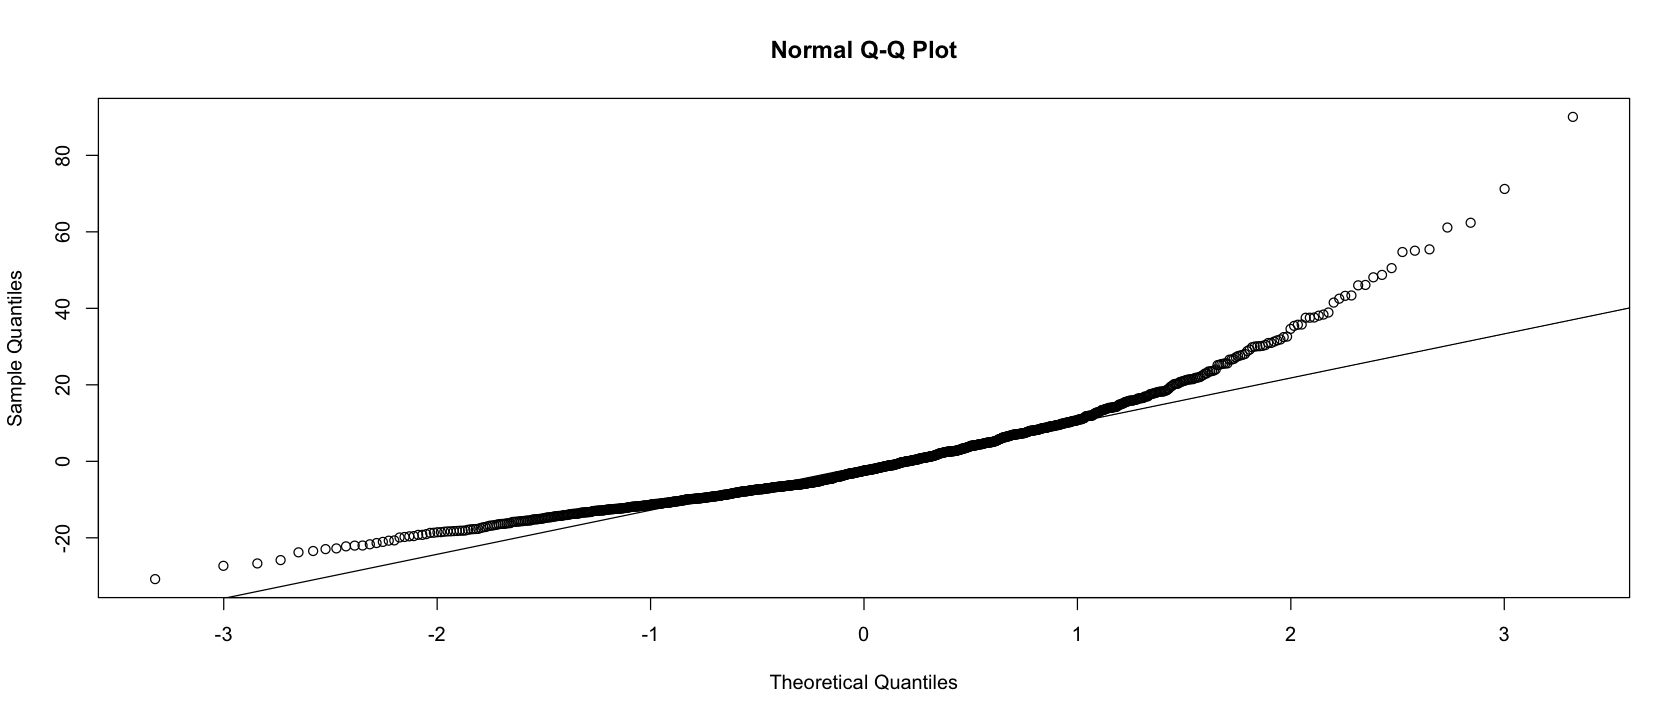

In [253]:
#diagnostics
leveneTest(mgN_tissue_P2~Phase_1_treat*Phase_2_treat, Tissue_Nutrients) 
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

### 4.2 Mg Carbon Analysis

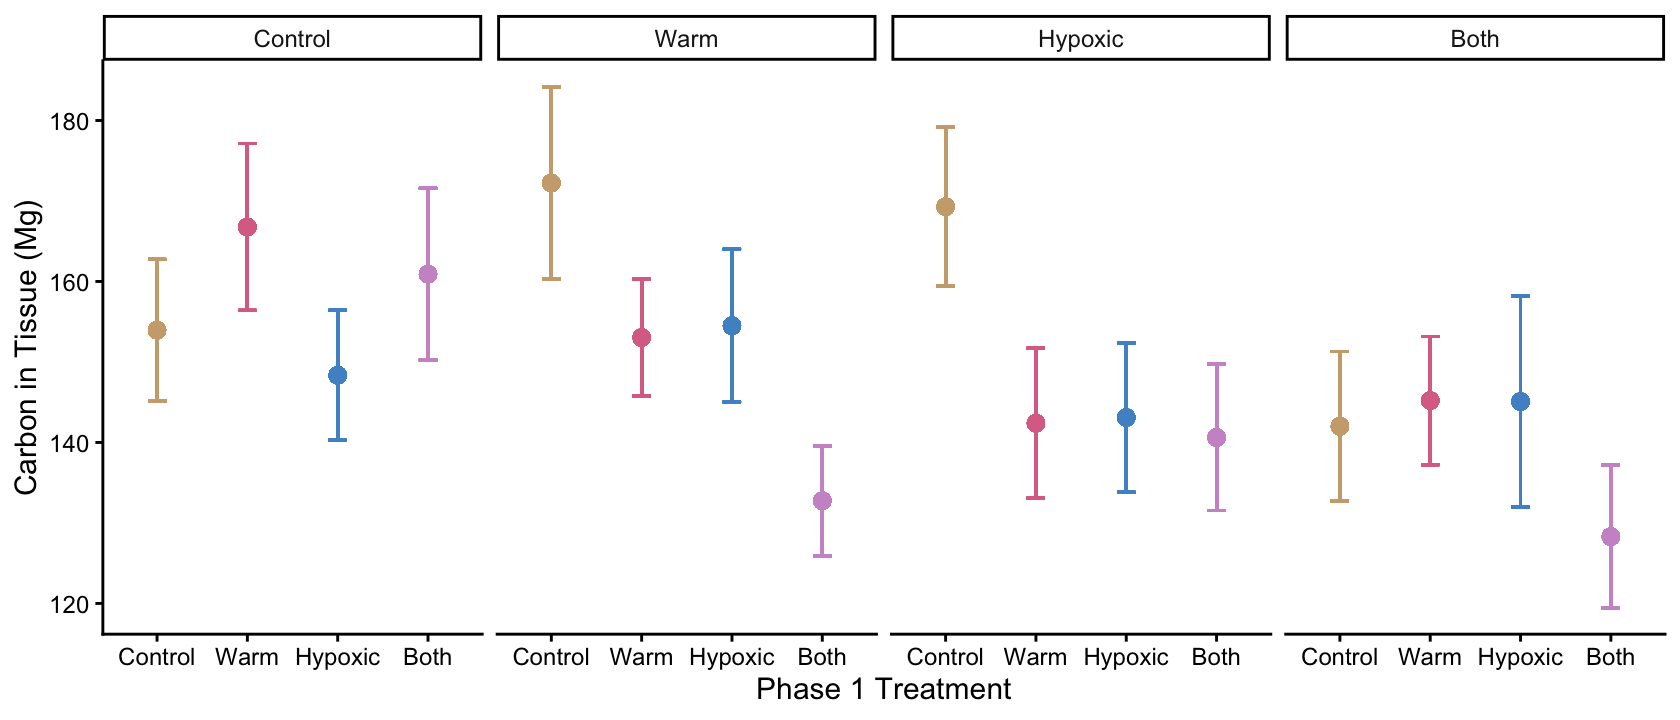

In [254]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Tissue_Nutrients %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgC_tissue_P2, na.rm = TRUE),
    se_growth = std.error(mgC_tissue_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Carbon in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [263]:
##tissue carbon
m1 <- lmer(mgC_tissue_P2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+ Actual_tissue_pre_mg+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.346819e+01,1,46.225117,0.0000
Phase_1_DO,3.650573e-01,1,10.693156,0.5583
Phase_1_temp,8.752793e+00,1,9.876744,0.0145
Phase_2.1_temp,2.657859e-01,1,19.941065,0.6118
Phase_2.1_DO,2.984221e+00,1,19.919417,0.0996
Actual_tissue_pre_mg,5.641330e+03,1,1031.152743,0.0000
Phase_1_DO:Phase_1_temp,1.835864e-02,1,9.877463,0.8949
Phase_1_DO:Phase_2.1_temp,1.551548e-01,1,19.961672,0.6978
Phase_1_temp:Phase_2.1_temp,5.386981e+00,1,19.971911,0.0310


In [256]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Ambient      Ambient        Hyp             142 4.91 25.6      132      152
 Warm         Ambient        Hyp             140 4.91 25.7      130      151
 Ambient      Warm           Hyp             151 4.90 25.4      141      161
 Warm         Warm           Hyp             151 4.93 26.0      140      161
 Ambient      Ambient        Norm            157 4.89 25.2      147      167
 Warm         Ambient        Norm            156 4.92 25.9      146      166
 Ambient      Warm           Norm            161 4.89 25.1      151      171
 Warm         Warm           Norm            142 4.91 25.7      132      152

Results are averaged over the levels of: Phase_1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate   SE   df t.ratio p.value
 Ambient Ambient Hyp - Warm Ambient Hyp        1.565 3.54 19.0   0.442  0.6634
 Am

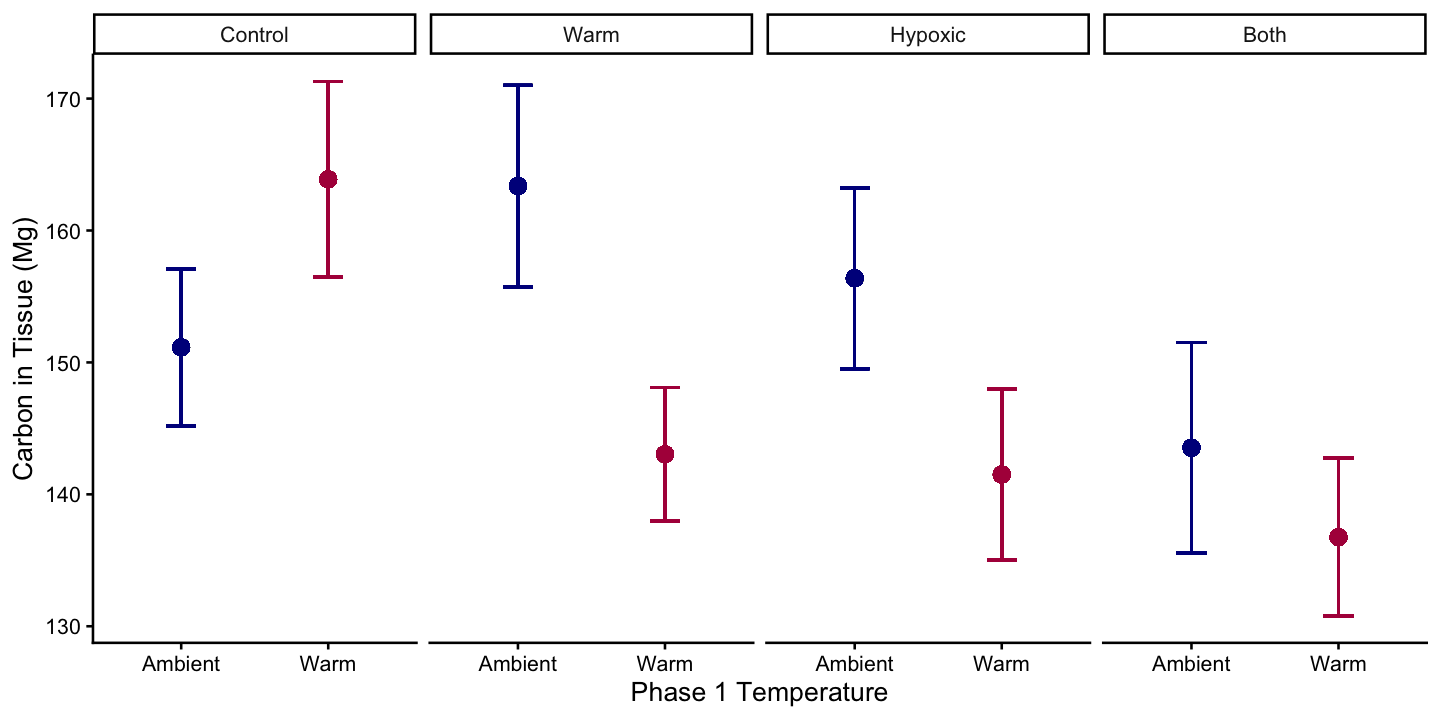

In [219]:
#format display for jupyter
options(repr.plot.width = 12, repr.plot.height = 6)

# plot Phase_1_temp:Phase_2.1_temp:Phase_2.1_DO tissue
summary_stats_t <- Tissue_Nutrients%>%
  group_by(Phase_1_temp, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgC_tissue_P2, na.rm = TRUE),
    se_growth = std.error(mgC_tissue_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                       levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))

#plot with mean and SD
ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(
    vars(Phase_2_treat),
    labeller = as_labeller(c(
      "Hyp" = "Hypoxic",
      "Cont" = "Control",
      "Warm" = "Warm",
      "Both" = "Both")), scales = "fixed", nrow = 1) +
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Carbon in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [ ]:
Ambient Ambient Hyp - Ambient Ambient Norm  -14.574 6.93 25.5  -2.104  0.0454
    ambient hyp - ambient cont
Ambient Ambient Hyp - Ambient Warm Norm     -18.668 6.92 25.5  -2.696  0.0122
    ambient hyp - ambient warm
Warm Ambient Hyp - Ambient Ambient Norm     -16.139 6.93 25.4  -2.329  0.0281
    warm hyp - ambient cont
Warm Ambient Hyp - Warm Ambient Norm        -15.455 6.96 26.0  -2.222  0.0352
    warm hyp - warm cont
Warm Ambient Hyp - Ambient Warm Norm        -20.233 6.93 25.4  -2.920  0.0072
    warm hyp - ambient warm
Ambient Ambient Norm - Warm Warm Norm        14.269 6.93 25.4   2.059  0.0498
    ambient cont - warm warm
Ambient Warm Norm - Warm Warm Norm           18.363 3.51 18.4   5.233 <0.0001
    ambient warm - warm warm

In [220]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO Phase_1_temp Phase_2.1_temp emmean   SE   df lower.CL upper.CL
 Hyp        Ambient      Ambient           146 3.90 36.1      138      153
 Norm       Ambient      Ambient           153 3.89 35.7      145      161
 Hyp        Warm         Ambient           154 3.93 37.2      146      162
 Norm       Warm         Ambient           143 3.92 36.8      135      150
 Hyp        Ambient      Warm              160 3.89 36.0      153      168
 Norm       Ambient      Warm              151 3.89 35.7      143      159
 Hyp        Warm         Warm              142 3.93 37.3      134      150
 Norm       Warm         Warm              151 3.91 36.7      143      159

Results are averaged over the levels of: Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate   SE   df t.ratio p.value
 Hyp Ambient Ambient - Norm Ambient Ambient   -7.653 3.56 26.2  -2.151  0.0409
 Hyp Ambient Ambien

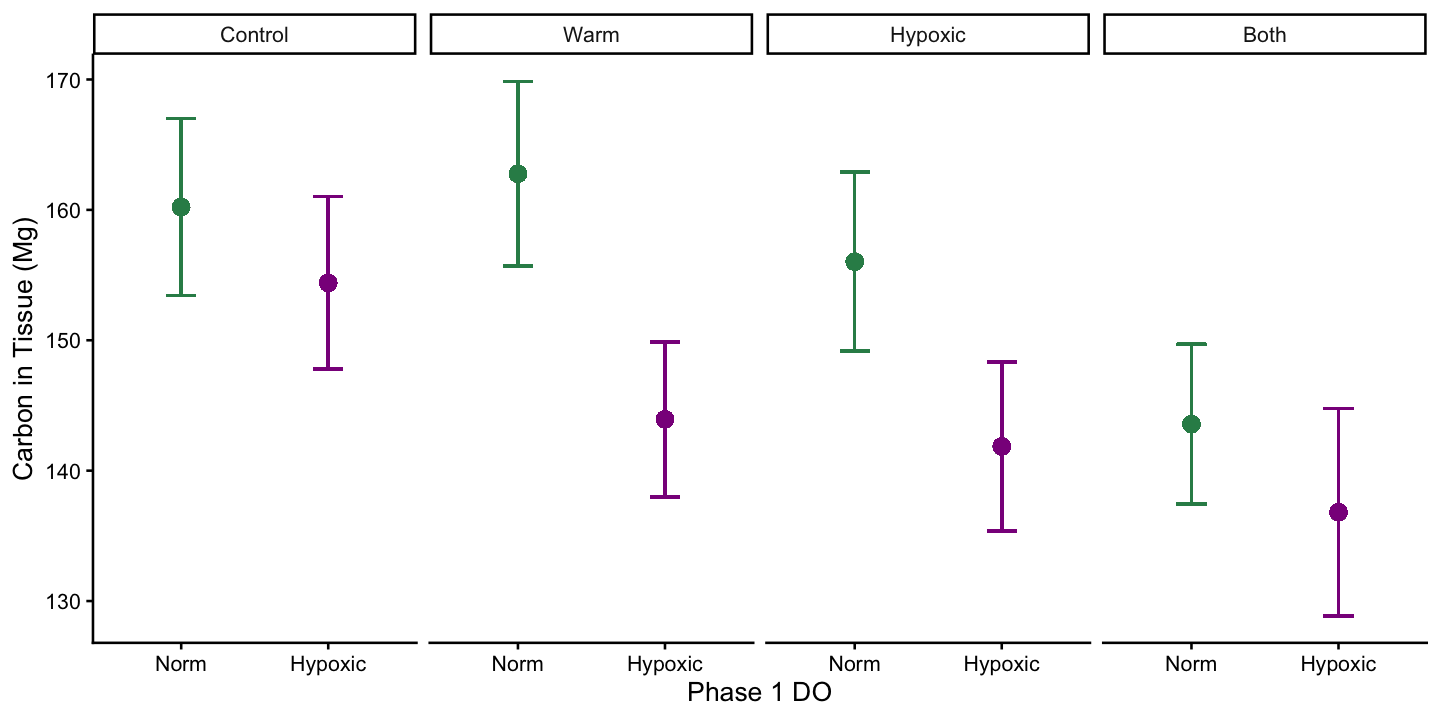

In [224]:
#format display for jupyter
options(repr.plot.width = 12, repr.plot.height = 6)

# plot Phase_1_temp:Phase_2.1_temp:Phase_2.1_DO tissue
summary_stats_t <- Tissue_Nutrients%>%
  group_by(Phase_1_DO, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgC_tissue_P2, na.rm = TRUE),
    se_growth = std.error(mgC_tissue_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_DO <- factor(summary_stats_t$Phase_1_DO, 
                                       levels = c("Norm", "Hyp"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))

#plot with mean and SD
ggplot(summary_stats_t, aes(x = Phase_1_DO, y = mean_growth, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(
    vars(Phase_2_treat),
    labeller = as_labeller(c(
      "Hyp" = "Hypoxic",
      "Cont" = "Control",
      "Warm" = "Warm",
      "Both" = "Both")), scales = "fixed", nrow = 1) +
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 1 DO", y = "Carbon in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend


### THIS GRAPH IS WRONG, NEEDS TO CHANGE.  SHOULD BE  Phase_1_DO*Phase_1_temp*Phase_2.1_temp

In [ ]:
#Hyp Ambient Ambient - Norm Ambient Ambient   -7.653 3.56 26.2  -2.151  0.0409
    hyp 
#Hyp Ambient Ambient - Hyp Warm Ambient       -8.351 3.54 26.9  -2.358  0.0259
#Hyp Ambient Ambient - Hyp Ambient Warm      -14.974 5.51 39.1  -2.718  0.0097
#Norm Ambient Ambient - Norm Warm Ambient     10.600 3.52 26.1   3.015  0.0057
#Hyp Warm Ambient - Norm Warm Ambient         11.299 3.62 28.1   3.117  0.0042
#Hyp Warm Ambient - Hyp Warm Warm             11.688 5.55 40.3   2.104  0.0416
#Norm Warm Ambient - Hyp Ambient Warm        -17.922 5.53 36.5  -3.242  0.0025
#Hyp Ambient Warm - Norm Ambient Warm          9.386 3.56 26.1   2.639  0.0138
#Hyp Ambient Warm - Hyp Warm Warm             18.310 3.54 26.7   5.178 <0.0001
#Hyp Ambient Warm - Norm Warm Warm             9.700 3.58 26.8   2.707  0.0116
#Norm Ambient Warm - Hyp Warm Warm             8.924 3.60 27.2   2.482  0.0195
#Hyp Warm Warm - Norm Warm Warm               -8.610 3.62 28.0  -2.377  0.0245

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.8875214,0.578296
,1101,NA,NA


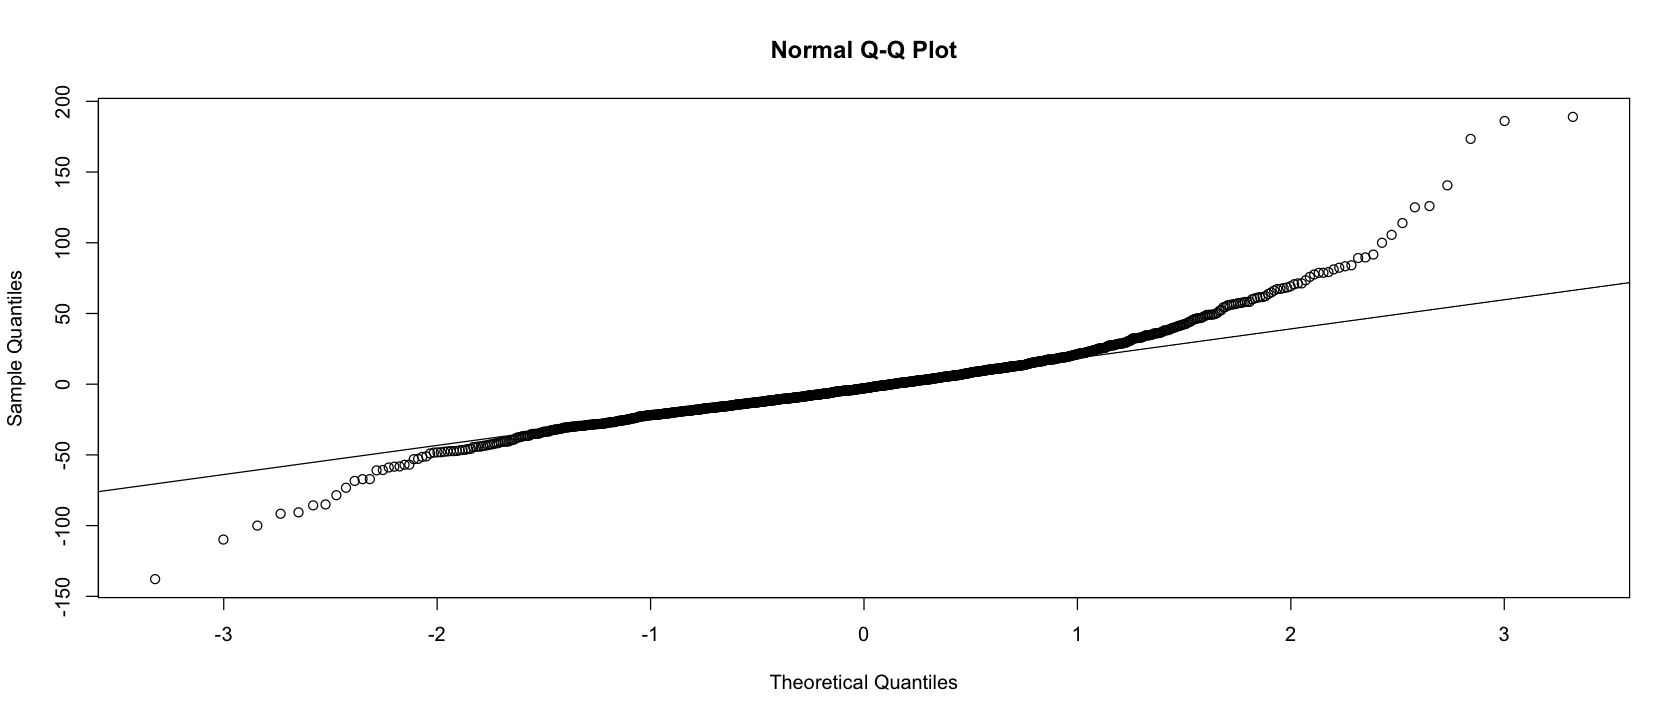

In [266]:
#diagnostics
leveneTest(mgC_tissue_P2~Phase_1_treat*Phase_2_treat, Tissue_Nutrients) 
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

# Shell

## 1. % Nitrogen in Shell

In [257]:
#filter data
Shell_Nitrogen <- df%>%
filter(Tissue_type == "S")%>%
filter(is.na(n_exclude))

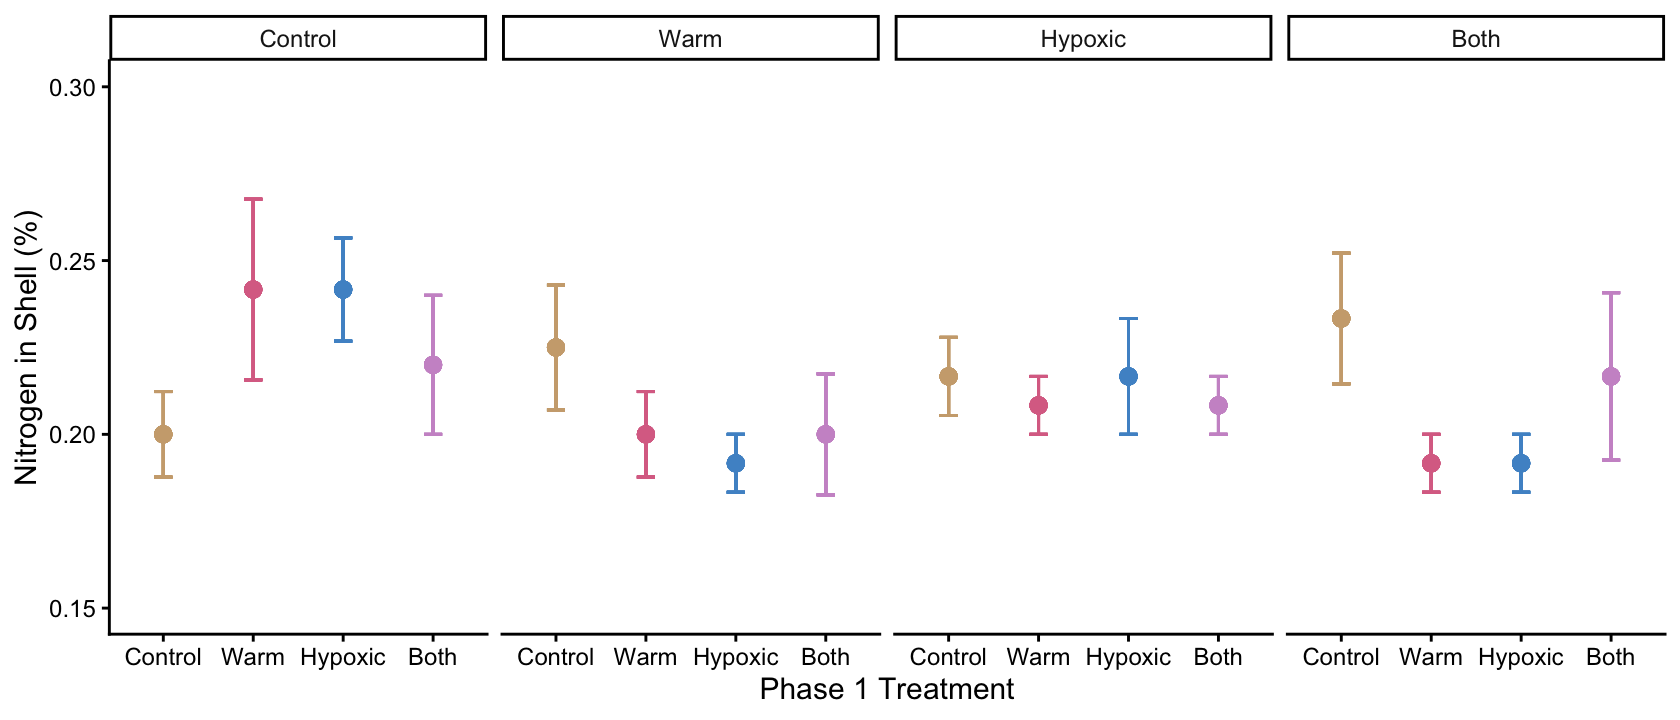

In [258]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Shell_Nitrogen %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(wt_percent_n, na.rm = TRUE),
    se_growth = std.error(wt_percent_n, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Nitrogen in Shell (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  ylim(0.15, 0.30)+
  theme(legend.position = "none") # Remove legend

In [267]:
##shell nitrogen
m1 <- lmer(wt_percent_n~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Nitrogen, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.346819e+01,1,46.225117,0.0000
Phase_1_DO,3.650573e-01,1,10.693156,0.5583
Phase_1_temp,8.752793e+00,1,9.876744,0.0145
Phase_2.1_temp,2.657859e-01,1,19.941065,0.6118
Phase_2.1_DO,2.984221e+00,1,19.919417,0.0996
Actual_tissue_pre_mg,5.641330e+03,1,1031.152743,0.0000
Phase_1_DO:Phase_1_temp,1.835864e-02,1,9.877463,0.8949
Phase_1_DO:Phase_2.1_temp,1.551548e-01,1,19.961672,0.6978
Phase_1_temp:Phase_2.1_temp,5.386981e+00,1,19.971911,0.0310


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.022584,0.4342068
,174,NA,NA


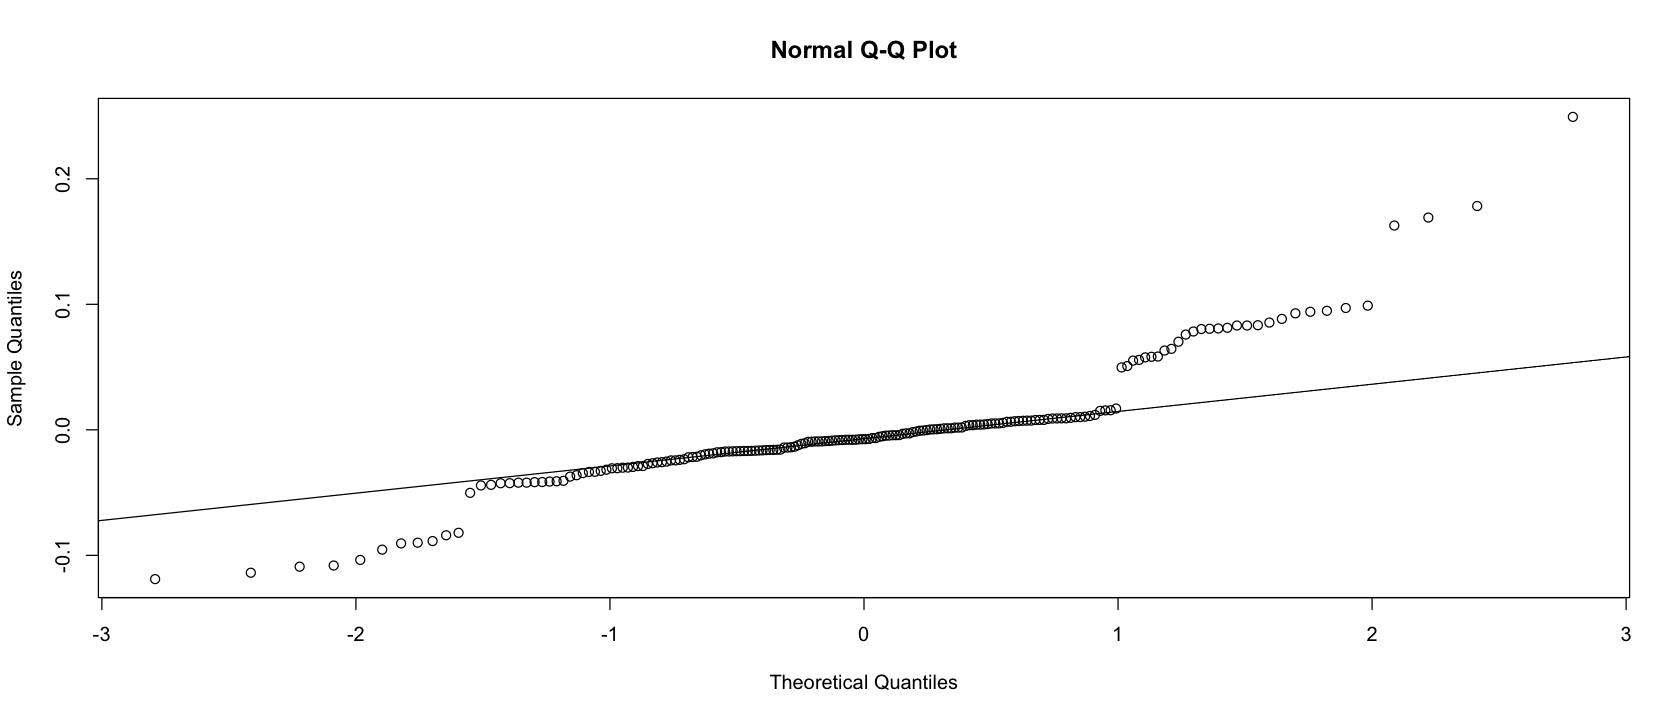

In [268]:
#diagnostics
leveneTest(wt_percent_n~Phase_1_treat*Phase_2_treat, Shell_Nitrogen) 
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

## 2. % Carbon in Shell

In [117]:
#filter data
Shell_Carbon <- df%>%
filter(Tissue_type == "S")%>%
filter(is.na(c_exclude))

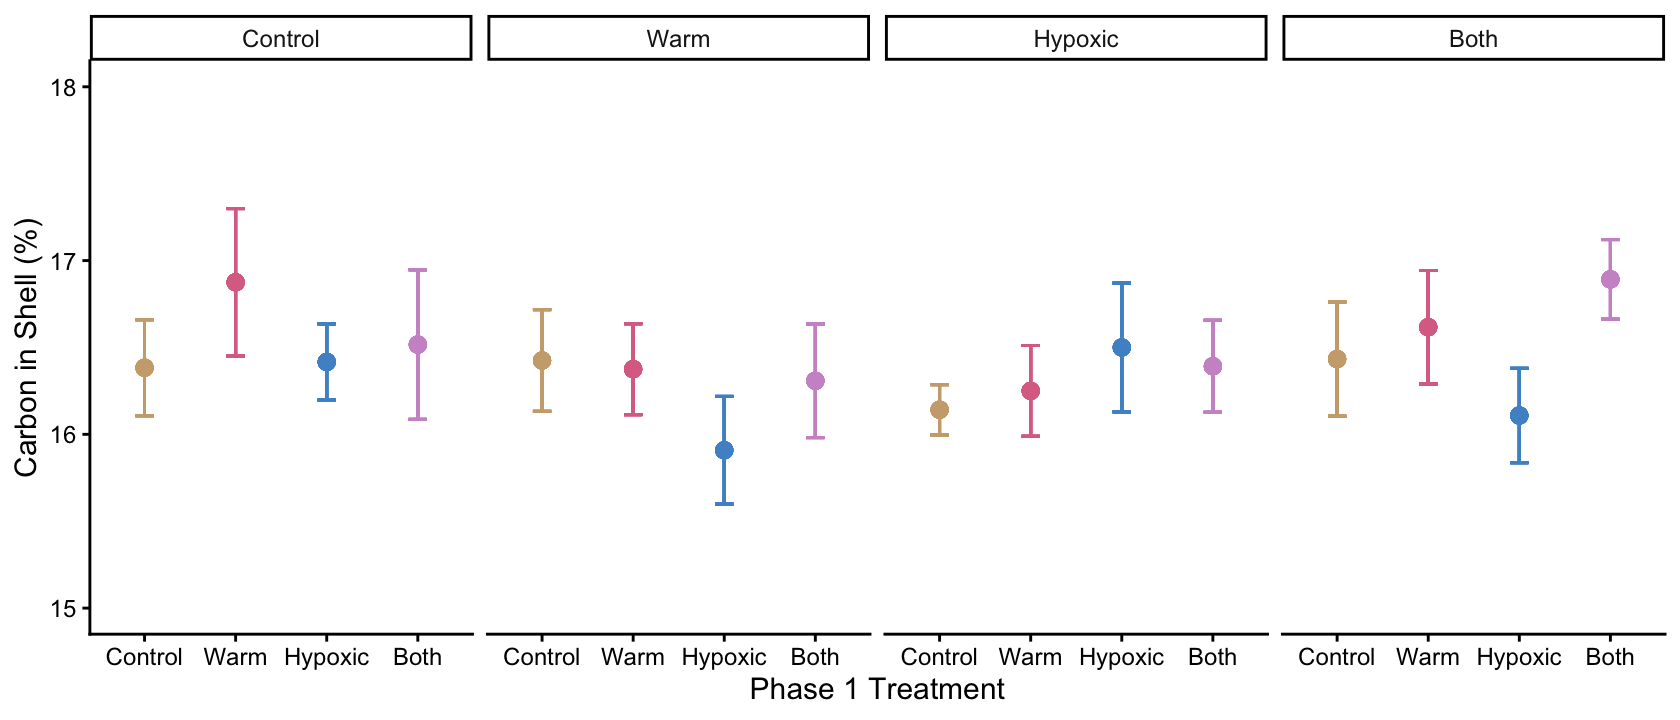

In [120]:
#tissue carbon
summary_stats_t <- Shell_Carbon %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(wt_percent_c, na.rm = TRUE),
    se_growth = std.error(wt_percent_c, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Carbon in Shell (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
ylim(15,18)+
  theme(legend.position = "none") # Remove legend

In [269]:
##Shell carbon
m2 <- lmer(wt_percent_c~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Carbon, REML=TRUE)
aov_tab<-Anova(m2, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.272049e+04,1,18.78179,0.0000
Phase_1_DO,1.302377e-01,1,13.00526,0.7240
Phase_1_temp,1.896658e+00,1,13.00274,0.1917
Phase_2.1_temp,5.720248e-02,1,19.32695,0.8135
Phase_2.1_DO,3.432965e-03,1,19.32695,0.9539
Phase_1_DO:Phase_1_temp,9.004444e-02,1,13.00513,0.7689
Phase_1_DO:Phase_2.1_temp,4.684673e-01,1,18.69820,0.5021
Phase_1_temp:Phase_2.1_temp,4.479149e-01,1,18.70035,0.5115
Phase_1_DO:Phase_2.1_DO,1.368940e+00,1,18.69820,0.2567


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.7521585,0.7285681
,176,NA,NA


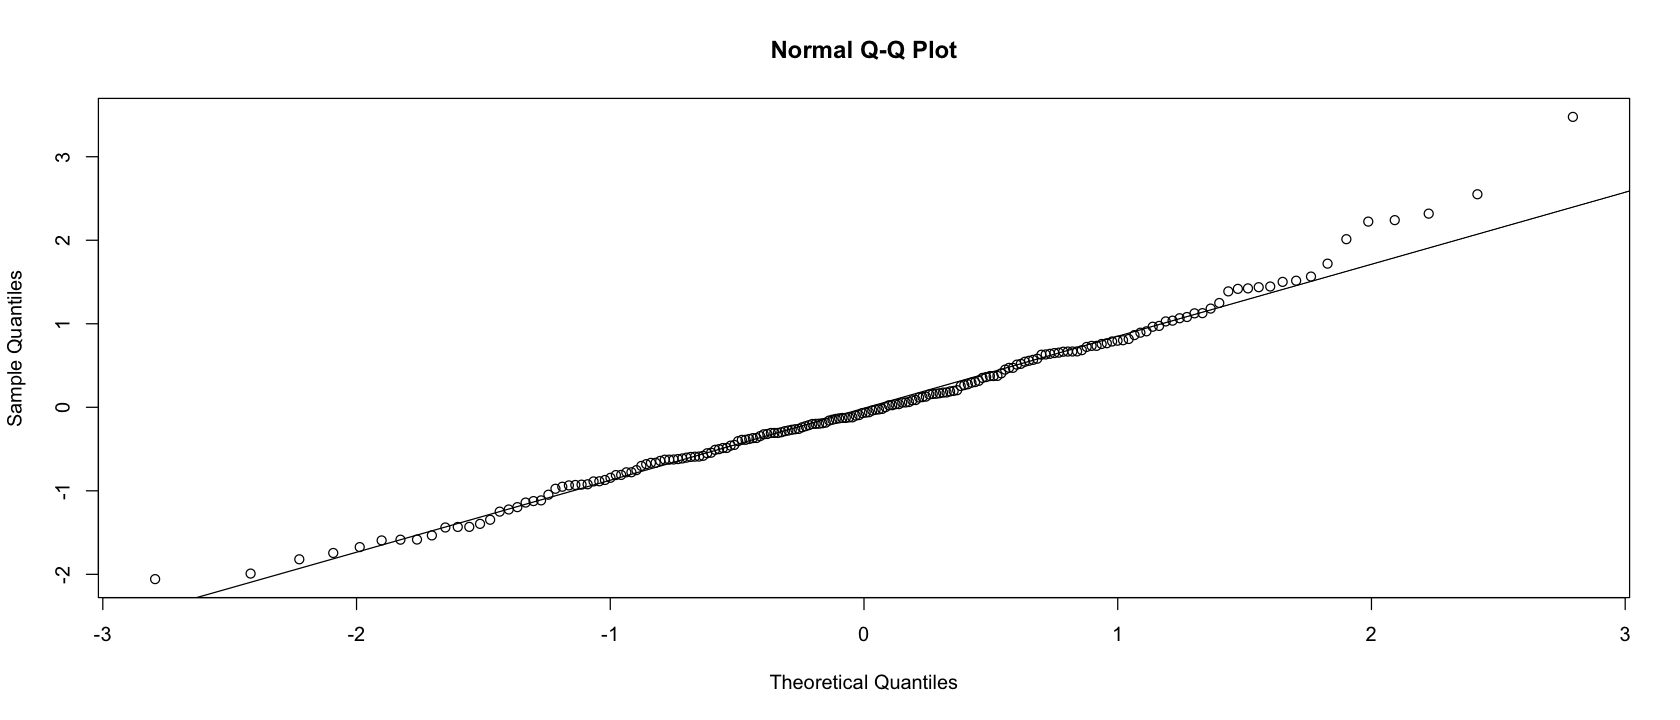

In [270]:
#diagnostics
leveneTest(wt_percent_c~Phase_1_treat*Phase_2_treat, Shell_Carbon) 
m1.e <- residuals(m2) 
qqnorm(m1.e)
qqline(m1.e)

## 3. Carbon:Nitrogen in Shell

In [273]:
#filter data
Shell_CN <- df%>%
filter(Tissue_type == "S")%>%
filter(is.na(n_exclude))%>%
filter(is.na(c_exclude))%>%
mutate(C_N = (wt_percent_c/wt_percent_n))

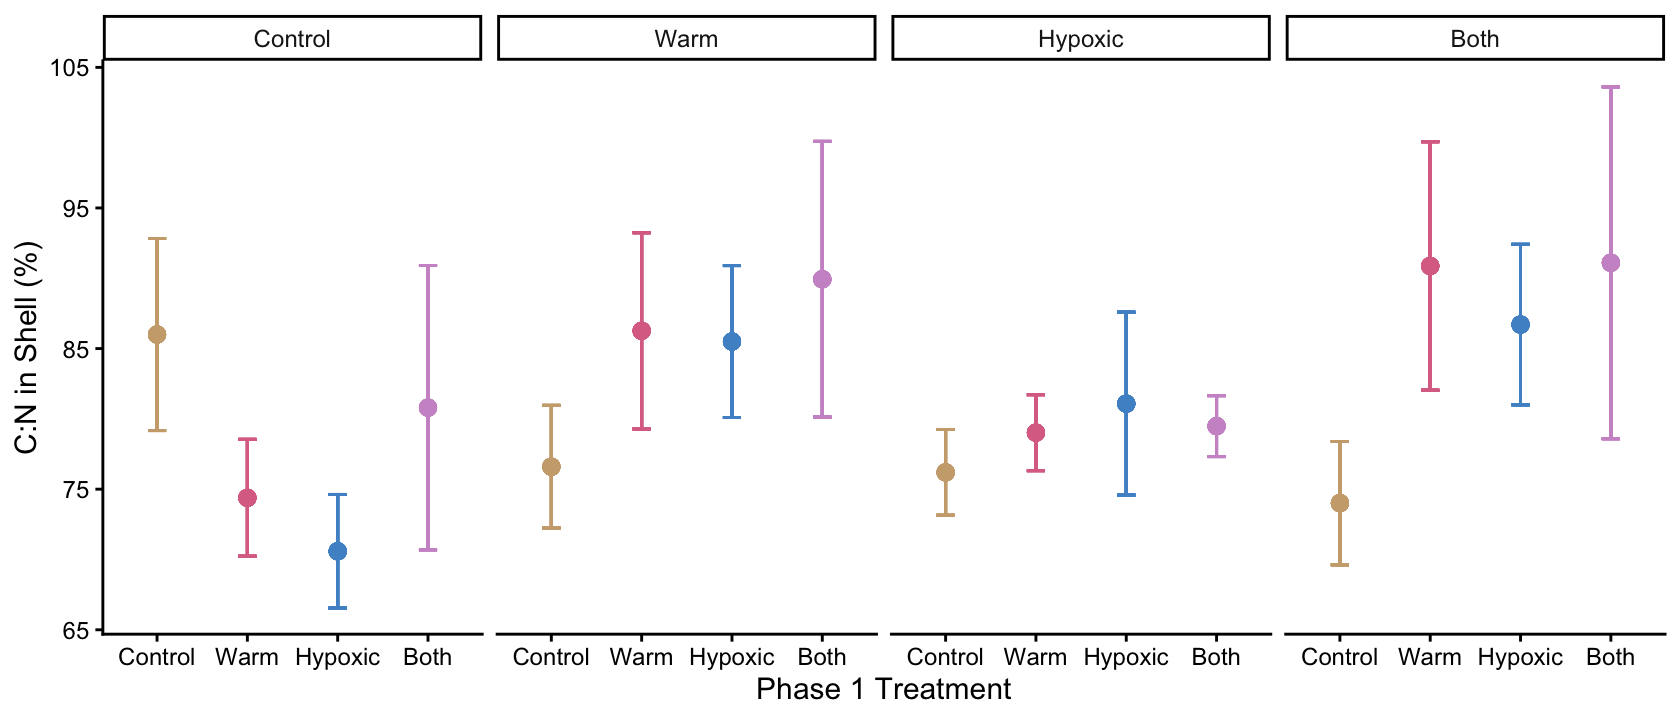

In [274]:
#tissue c:n
summary_stats_t <- Shell_CN %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(C_N, na.rm = TRUE),
    se_growth = std.error(C_N, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "C:N in Shell (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [127]:
##shell carbon:nitrogen
m3 <- lmer((wt_percent_c/wt_percent_n)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_CN, REML=TRUE)
aov_tab<-Anova(m3, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.574742e+03,1,14.68914,0.0000
Phase_1_DO,3.676224e-01,1,10.52370,0.5572
Phase_1_temp,1.231866e+00,1,10.52333,0.2918
Phase_2.1_temp,3.421284e+00,1,19.77954,0.0794
Phase_2.1_DO,2.086412e-01,1,19.77954,0.6528
Phase_1_DO:Phase_1_temp,5.242249e-02,1,10.52370,0.8233
Phase_1_DO:Phase_2.1_temp,1.886709e+00,1,19.58366,0.1851
Phase_1_temp:Phase_2.1_temp,2.618342e+00,1,19.58384,0.1216
Phase_1_DO:Phase_2.1_DO,6.598977e-01,1,19.58366,0.4264


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.9179332,0.5453829
,174,NA,NA


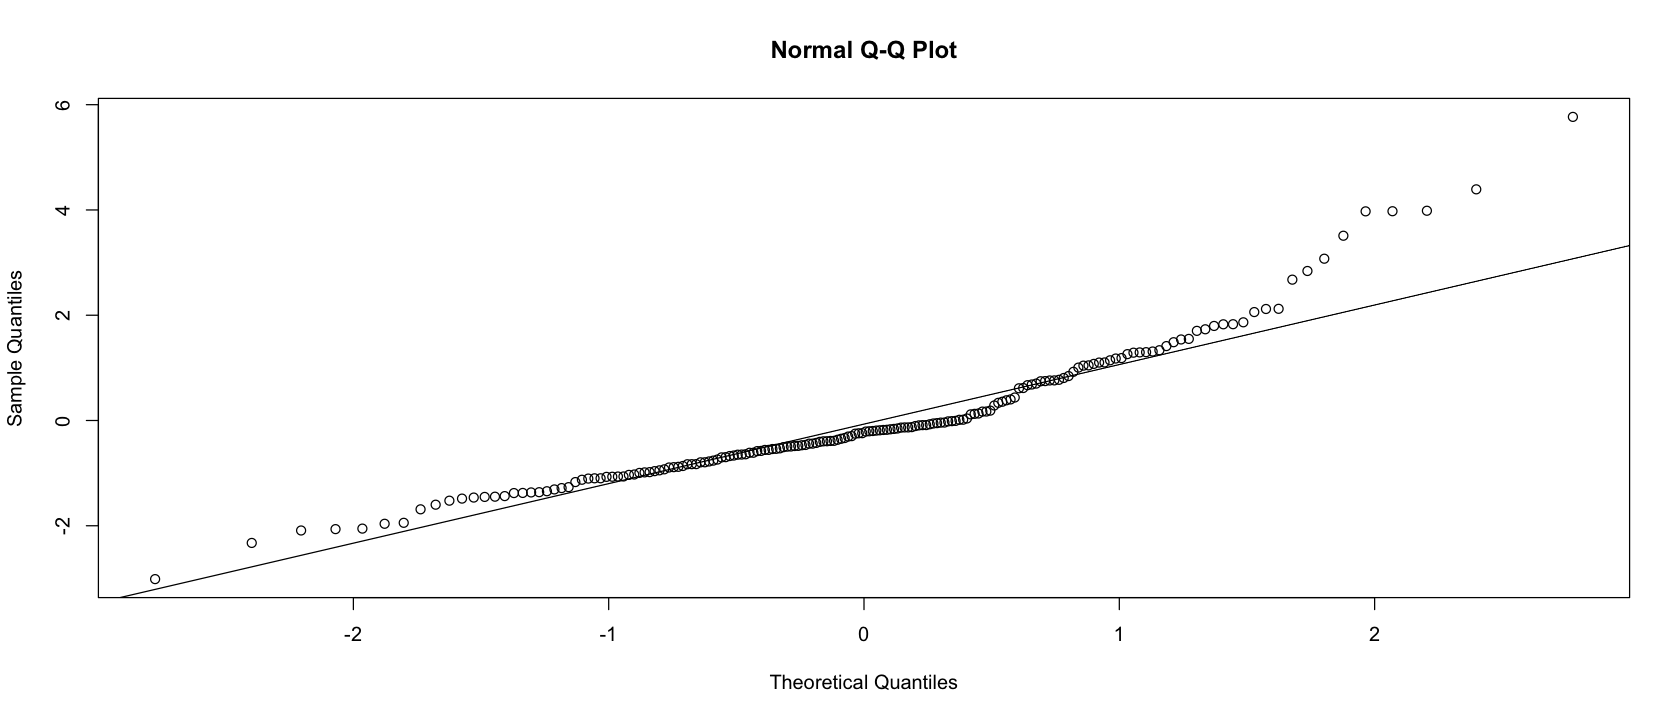

In [275]:
#diagnostics
leveneTest(C_N~Phase_1_treat*Phase_2_treat, Shell_CN) 
m1.e <- residuals(m3) 
qqnorm(m1.e)
qqline(m1.e)

## 4. Mg Carbon and Nitrogen in Shell

In [276]:
#calculate % N averages Tissue

summary_stats_s <- Shell_CN %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  summarize(
    mean_N = mean(wt_percent_n, na.rm = TRUE),
    mean_C = mean(wt_percent_c, na.rm = TRUE))

print(summary_stats_s)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Phase_1_treat and Phase_2_treat.
ℹ Output is grouped by Phase_1_treat.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Phase_1_treat, Phase_2_treat))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


# A tibble: 16 × 4
# Groups:   Phase_1_treat [4]
   Phase_1_treat Phase_2_treat mean_N mean_C
   <chr>         <chr>          <dbl>  <dbl>
 1 Both          Both           0.217   16.8
 2 Both          Cont           0.22    16.2
 3 Both          Hyp            0.208   16.4
 4 Both          Warm           0.2     16.3
 5 Cont          Both           0.233   16.4
 6 Cont          Cont           0.2     16.4
 7 Cont          Hyp            0.217   16.1
 8 Cont          Warm           0.225   16.4
 9 Hyp           Both           0.192   16.1
10 Hyp           Cont           0.242   16.4
11 Hyp           Hyp            0.217   16.5
12 Hyp           Warm           0.192   15.9
13 Warm          Both           0.192   16.6
14 Warm          Cont           0.242   16.9
15 Warm          Hyp            0.208   16.2
16 Warm          Warm           0.2     16.4


In [156]:
Shell_Nutrients <- weight_df %>%
  filter(Exclude_all != "Y" | is.na(Exclude_all)) %>%
  left_join(
    summary_stats_s,
    by = c("Phase_1_treat", "Phase_2_treat")) %>%
  mutate(mgN_shell_P2 = (Actual_shell_post_mg * mean_N) / 100)%>%
  mutate(mgC_shell_P2 = (Actual_shell_post_mg * mean_C) / 100)

View(Shell_Nutrients)

Sample_Name,Order_pre,Date_MMDDYYYY_pre,Year,Phase_1_treat,Phase_1_rep,Phase_2_treat,Phase_2_rep,Tag_color,Tag_num,⋯,Phase_1_rep_R,Phase_2_rep_R,Ratio_tissue_shell_pre_mg,Phase1_Phase2_rep,Exclude_all,Exclude_pre_analysis,mean_N,mean_C,mgN_shell_P2,mgC_shell_P2
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2024_Both01_Both01_O1,3,7/23/24,2024,Both,01,Both,01,O,1,⋯,Both01,Both01,0.9025393,Both01_Both01,NA,NA,0.2166667,16.89167,1.1734008,91.48013
2024_Both01_Both01_O2,7,7/23/24,2024,Both,01,Both,01,O,2,⋯,Both01,Both01,0.6425681,Both01_Both01,NA,NA,0.2166667,16.89167,1.3288115,103.59619
2024_Both01_Both02_O13,50,7/23/24,2024,Both,01,Both,02,O,13,⋯,Both01,Both02,0.8083796,Both01_Both02,NA,NA,0.2166667,16.89167,1.5754788,122.82675
2024_Both01_Both02_O14,55,7/23/24,2024,Both,01,Both,02,O,14,⋯,Both01,Both02,0.5888140,Both01_Both02,NA,NA,0.2166667,16.89167,1.4200681,110.71070
2024_Both01_Both03_O25,98,7/24/24,2024,Both,01,Both,03,O,25,⋯,Both01,Both03,0.7725658,Both01_Both03,NA,NA,0.2166667,16.89167,0.4196760,32.71859
2024_Both01_Both03_O26,103,7/24/24,2024,Both,01,Both,03,O,26,⋯,Both01,Both03,0.5599379,Both01_Both03,NA,NA,0.2166667,16.89167,0.9977490,77.78604
2024_Both01_Both04_O37,214,7/24/24,2024,Both,01,Both,04,O,37,⋯,Both01,Both04,0.7191106,Both01_Both04,NA,NA,0.2166667,16.89167,2.2815169,177.87057
2024_Both01_Both04_O38,111,7/24/24,2024,Both,01,Both,04,O,38,⋯,Both01,Both04,0.5380885,Both01_Both04,NA,NA,0.2166667,16.89167,0.3963472,30.89984
2024_Both01_Both05_O49,260,7/25/24,2024,Both,01,Both,05,O,49,⋯,Both01,Both05,0.5206603,Both01_Both05,NA,NA,0.2166667,16.89167,1.3401328,104.47882


### 4.1 Mg Nitrogen Analysis

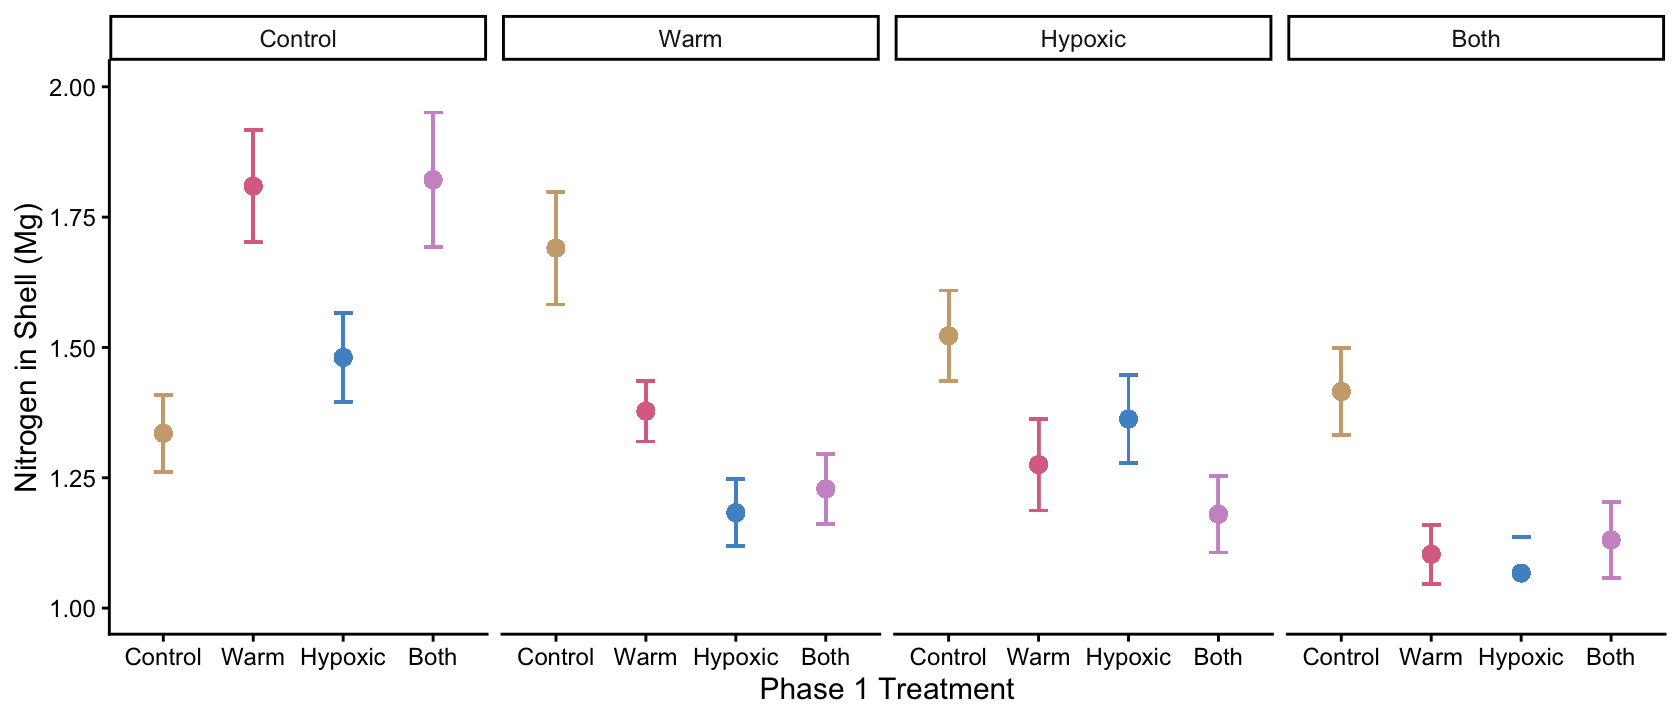

In [160]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Shell_Nutrients %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgN_shell_P2, na.rm = TRUE),
    se_growth = std.error(mgN_shell_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Nitrogen in Shell (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  ylim(1,2)+
  theme(legend.position = "none") # Remove legend

In [279]:
##shell nitrogen
m1 <- lmer(log(mgN_shell_P2)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),14.77985382,1,21.28009,0.0009
Phase_1_DO,11.19688525,1,16.12409,0.0041
Phase_1_temp,0.34375540,1,13.94367,0.5670
Phase_2.1_temp,1.76911124,1,20.00035,0.1985
Phase_2.1_DO,3.34565990,1,20.00056,0.0823
Phase_1_DO:Phase_1_temp,2.40449110,1,13.94811,0.1434
Phase_1_DO:Phase_2.1_temp,7.99549854,1,19.99935,0.0104
Phase_1_temp:Phase_2.1_temp,4.62675505,1,19.98383,0.0439
Phase_1_DO:Phase_2.1_DO,0.20973061,1,20.00183,0.6519


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.9542526,0.5025115
,1101,NA,NA


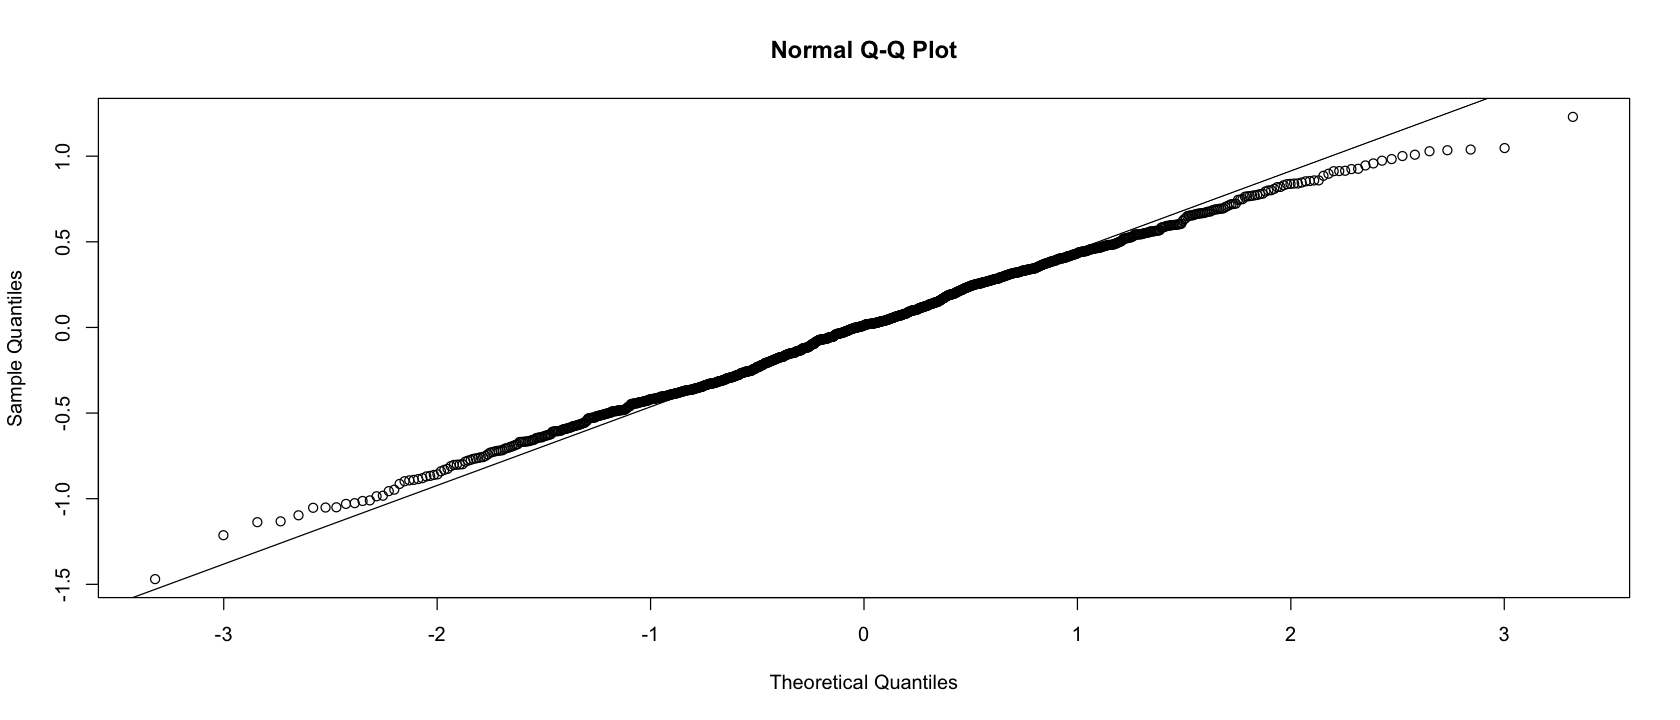

In [280]:
#diagnostics
leveneTest(log(mgN_shell_P2)~Phase_1_treat*Phase_2_treat, Shell_Nutrients) #FAILS LEVENE TEST
m1.e <- residuals(m1)
qqnorm(m1.e)
qqline(m1.e)

### 4.2 Mg Carbon Analysis

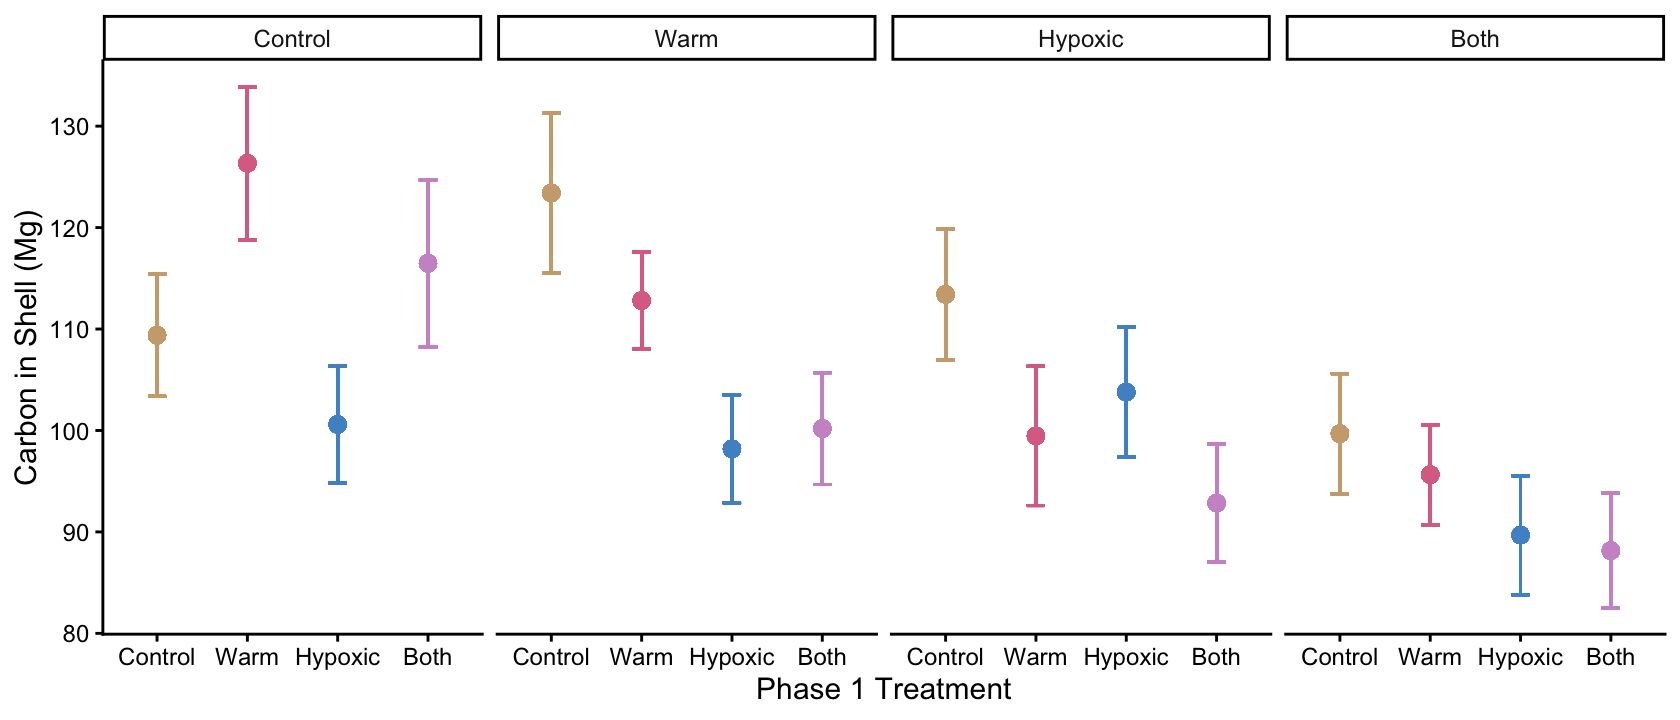

In [259]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Shell_Nutrients %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgC_shell_P2, na.rm = TRUE),
    se_growth = std.error(mgC_shell_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Carbon in Shell (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [260]:
##Shell carbon
    #using tissue pre as a covariate
m1 <- lmer(mgC_shell_P2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+ Actual_tissue_pre_mg+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.108161e+02,1,51.36879,0.0000
Phase_1_DO,5.144037e+00,1,13.20620,0.0407
Phase_1_temp,1.051415e-01,1,13.76883,0.7506
Phase_2.1_temp,1.805551e-01,1,19.93525,0.6754
Phase_2.1_DO,1.057583e+01,1,19.91232,0.0040
Actual_tissue_pre_mg,3.223048e+03,1,1039.24668,0.0000
Phase_1_DO:Phase_1_temp,1.593273e+00,1,13.04722,0.2290
Phase_1_DO:Phase_2.1_temp,2.129354e+00,1,19.95804,0.1601
Phase_1_temp:Phase_2.1_temp,1.044773e+00,1,19.97434,0.3189


In [261]:
##Shell carbon
    #using shell pre as a covariate
m1 <- lmer(mgC_shell_P2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+ Actual_shell_pre_mg+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),5.253585e+01,1,33.33220,0.0000
Phase_1_DO,3.365075e-01,1,10.57533,0.5740
Phase_1_temp,6.458072e+00,1,11.91696,0.0260
Phase_2.1_temp,1.156283e-06,1,19.98958,0.9992
Phase_2.1_DO,8.011631e+00,1,19.97523,0.0103
Actual_shell_pre_mg,7.596008e+03,1,1074.17990,0.0000
Phase_1_DO:Phase_1_temp,9.515288e-01,1,10.30751,0.3517
Phase_1_DO:Phase_2.1_temp,1.210096e+00,1,19.95013,0.2844
Phase_1_temp:Phase_2.1_temp,1.649227e-01,1,19.98922,0.6890


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.675162,0.05006165
,1101,NA,NA


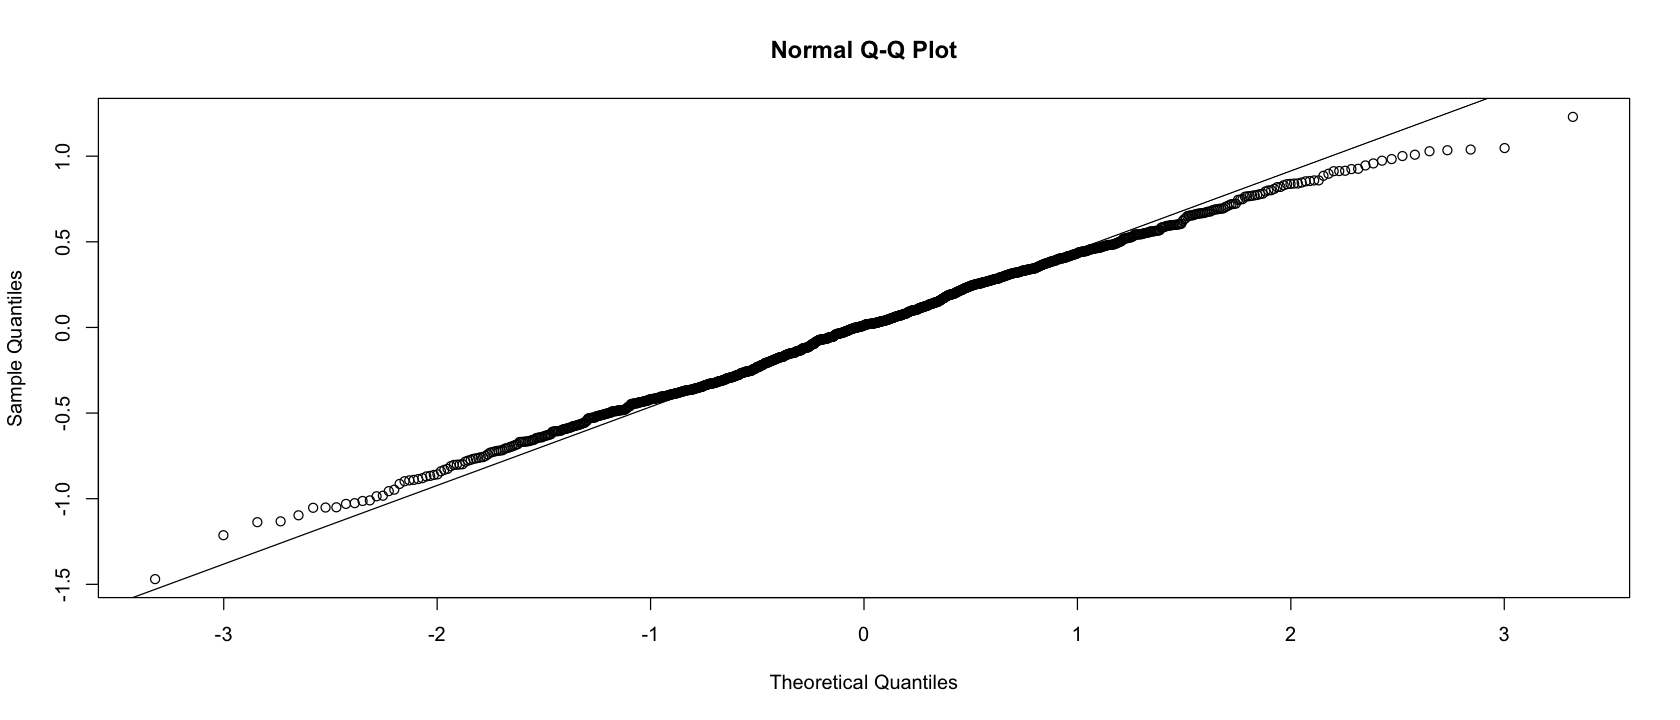

In [281]:
#diagnostics
leveneTest(mgC_shell_P2~Phase_1_treat*Phase_2_treat, Shell_Nutrients)
m1.e <- residuals(m1)
qqnorm(m1.e)
qqline(m1.e)